# Bet Positions — Who bet YES vs NO, and who won?

**Polymarket mechanics:**
- `BUY YES` = new money staked that the event **WILL** happen
- `BUY NO` = new money staked that the event **WON'T** happen
- `SELL YES/NO` = closing / exiting an existing position

Each chart shows the actual position direction (YES vs NO), bet sizes over time, and highlights which side won at resolution.

---

In [1]:
import warnings; warnings.filterwarnings('ignore')
import httpx, os
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path
from datetime import datetime, timedelta

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 10,
                     'axes.labelsize': 9, 'xtick.labelsize': 7,
                     'ytick.labelsize': 7, 'legend.fontsize': 7})

EDA     = Path('.')
# Colours by DIRECTION (outcome), not BUY/SELL
C_YES   = '#2ea043'   # green  — bet the event WILL happen
C_NO    = '#cf222e'   # red    — bet the event WON'T happen
C_PRICE = '#0075ca'
C_NET   = '#6e40c9'

fmt_usdc = mticker.FuncFormatter(
    lambda v, _: f'\${abs(v)/1e6:.1f}M' if abs(v) >= 1e6
    else f'\${abs(v)/1e3:.0f}K' if abs(v) >= 1e3 else f'\${abs(v):.0f}'
)

<>:29: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
<>:29: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_87283/2847901947.py:29: SyntaxWarning: invalid escape sequence '\$'
  lambda v, _: f'\${abs(v)/1e6:.1f}M' if abs(v) >= 1e6
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_87283/2847901947.py:30: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v) >= 1e3 else f'\${abs(v):.0f}'
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_87283/2847901947.py:30: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v) >= 1e3 else f'\${abs(v):.0f}'


In [2]:
PRICE_SCHEMA = {'timestamp': pl.Int64, 'price': pl.Float64}
markets = pl.read_csv(EDA / 'markets.csv')

def load_ph(slug):
    p = EDA / slug / 'price_history.csv'
    if not p.exists(): return pl.DataFrame()
    return (
        pl.read_csv(p, schema_overrides=PRICE_SCHEMA)
        .with_columns((pl.col('timestamp') * 1_000_000)
                       .cast(pl.Datetime('us')).alias('date'))
    )

def fetch_all_trades(condition_id):
    rows, seen = [], set()
    with httpx.Client(base_url='https://data-api.polymarket.com', timeout=30) as client:
        for offset in range(0, 3000, 500):
            try:
                data = client.get('/trades',
                    params={'market': condition_id, 'limit': 500, 'offset': offset}
                ).json()
                if not isinstance(data, list) or not data: break
                for r in data:
                    h = r.get('transactionHash', str(r.get('timestamp','')))
                    if h not in seen:
                        seen.add(h)
                        rows.append(r)
                if len(data) < 500: break
            except Exception: break
    if not rows: return pl.DataFrame()
    return (
        pl.DataFrame({
            'timestamp': [int(r.get('timestamp', 0))  for r in rows],
            'price':     [float(r.get('price', 0))    for r in rows],
            'size':      [float(r.get('size', 0))     for r in rows],
            'side':      [str(r.get('side', ''))      for r in rows],
            'outcome':   [str(r.get('outcome', ''))   for r in rows],
        })
        .sort('timestamp')
        .with_columns(
            (pl.col('timestamp') * 1_000_000).cast(pl.Datetime('us')).alias('date'),
            # Normalise outcome to 'Yes' / 'No'
            pl.when(pl.col('outcome').str.to_lowercase() == 'yes').then(pl.lit('Yes'))
              .when(pl.col('outcome').str.to_lowercase() == 'no').then(pl.lit('No'))
              .otherwise(pl.col('outcome')).alias('outcome')
        )
    )

print(f'{len(markets)} markets ready')

20 markets ready


## Per-market charts

**Panel 1 — individual bets:**  
● filled circle = **BUY** (new money entering)  
▲ triangle = **SELL** (exiting a position)  
Green = bet YES (event will happen) | Red = bet NO (event won't happen)

**Panel 2 — cumulative money flow:**  
Green = total BUY YES staked | Red = total BUY NO staked | Purple = net (YES − NO)

Resolution banner shows who won.

Fetching: Will Donald Trump win the 2024 US Presidential Election?


  3000 fills  span=0.1d
  BUY YES (event happens) : \$  13,930K  (91%)
  BUY NO  (event won't)   : \$   1,446K  (9%)
  Resolution → Yes  |  YES bettors WON  |  NO bettors LOST



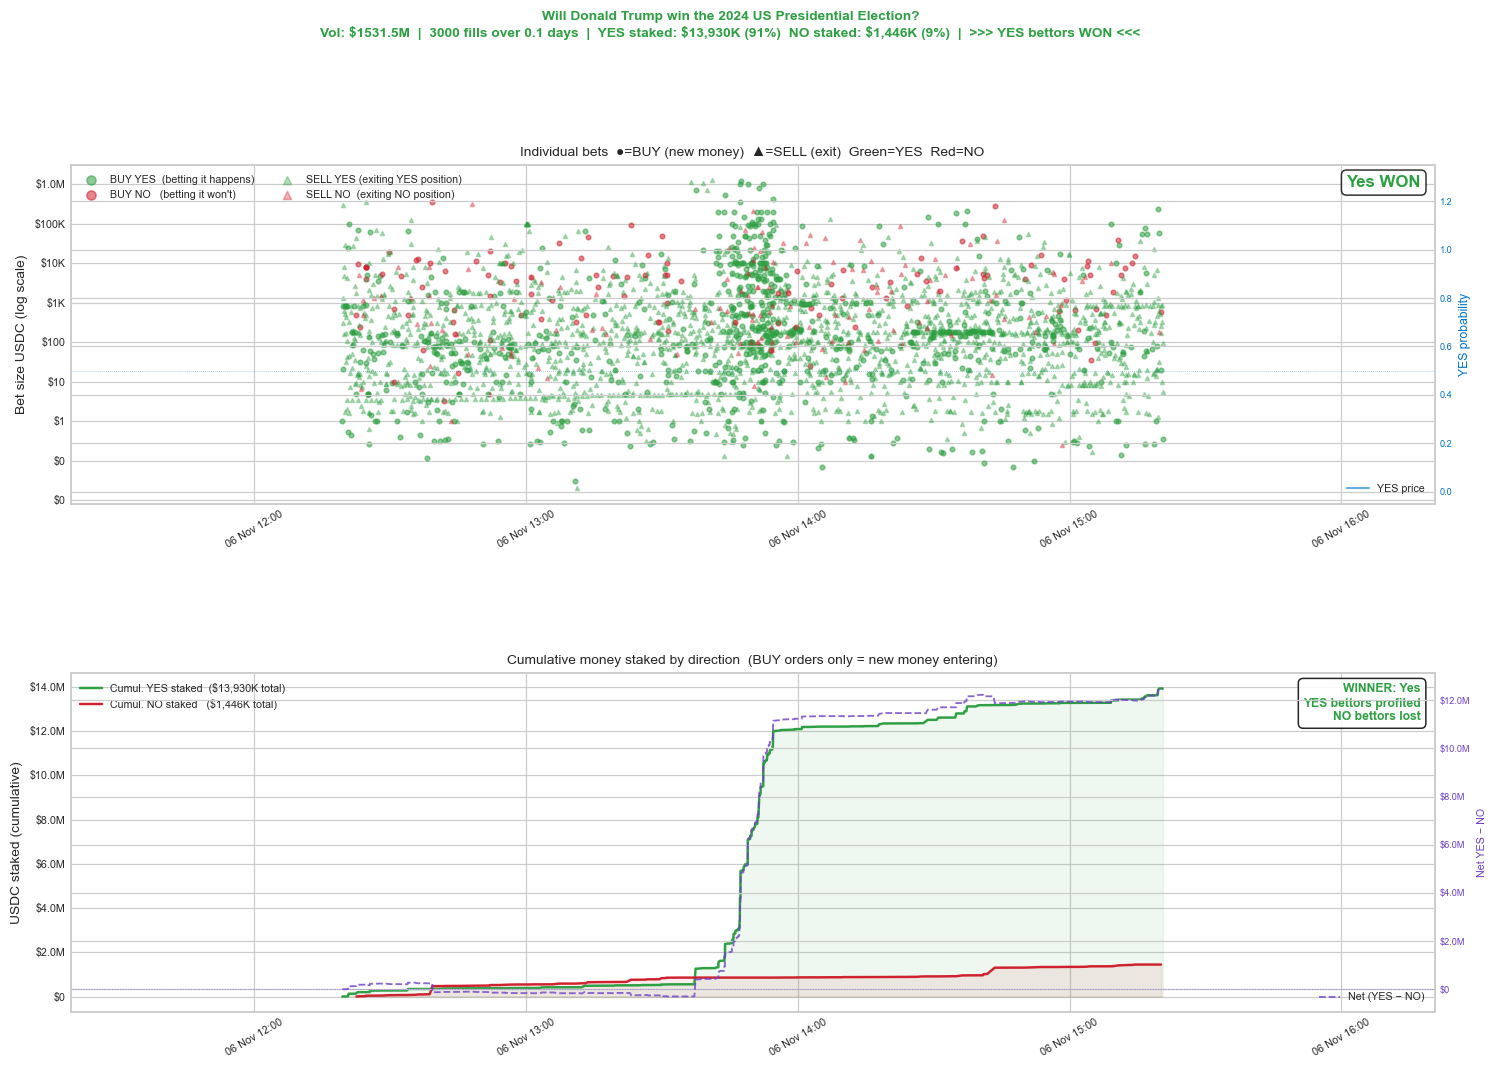

Fetching: Will Kamala Harris win the 2024 US Presidential Election?


  3000 fills  span=0.5d
  BUY YES (event happens) : \$  18,467K  (99%)
  BUY NO  (event won't)   : \$     276K  (1%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



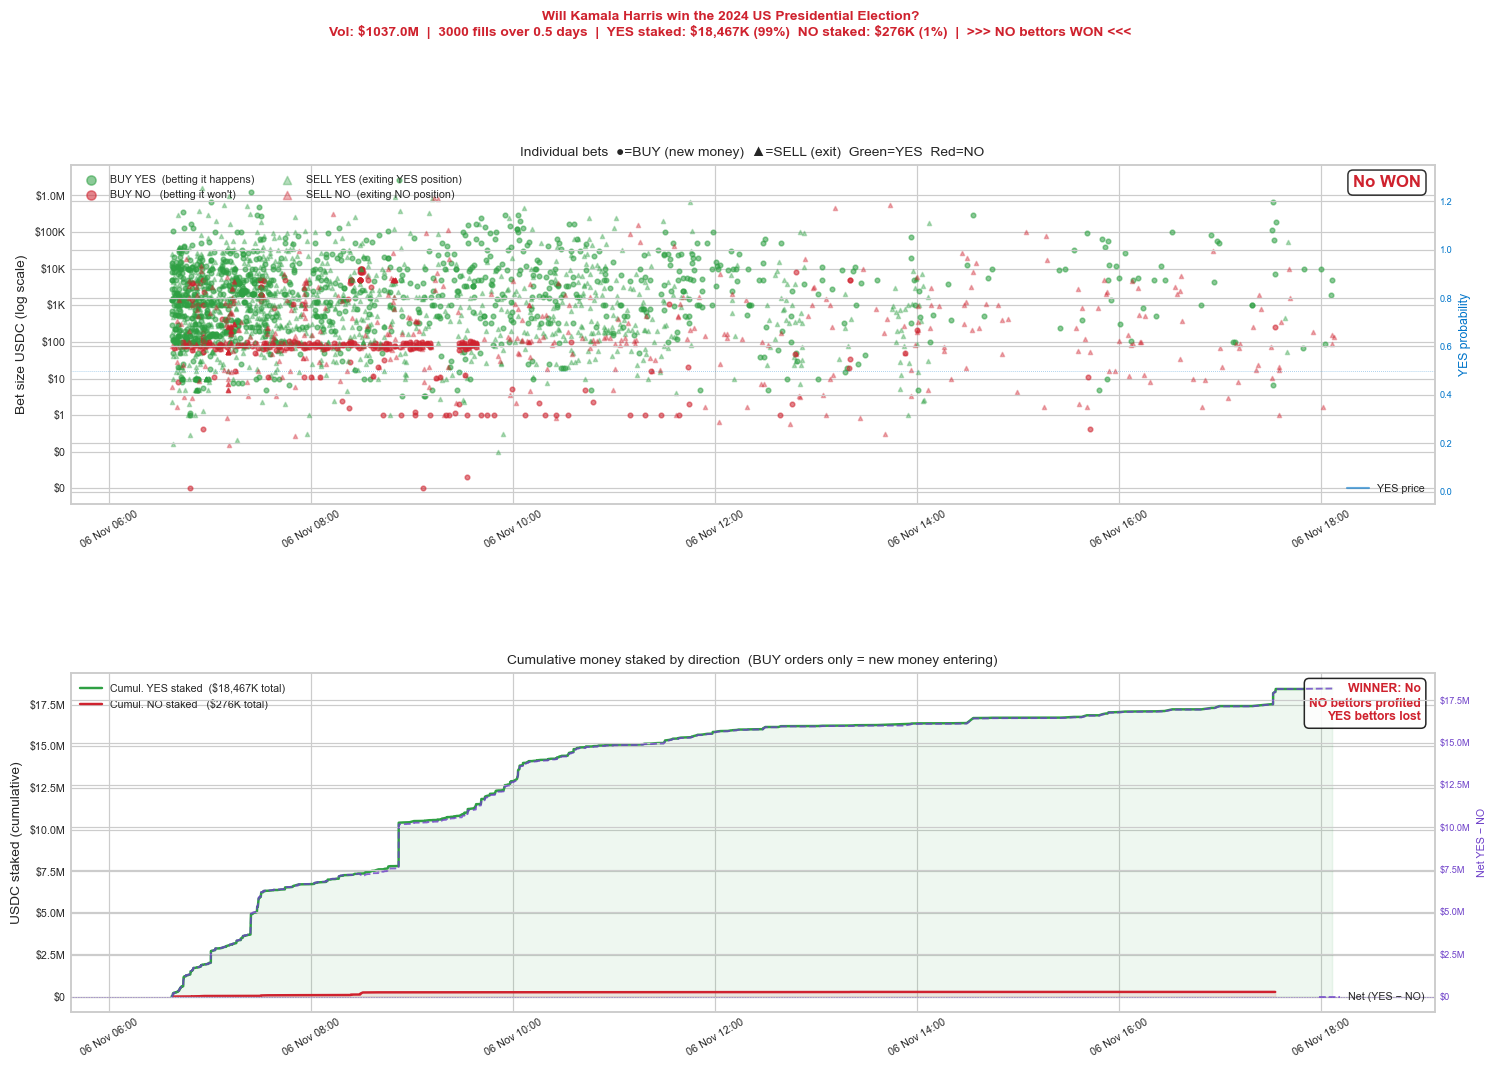

Fetching: Will Donald Trump be inaugurated?


  3000 fills  span=0.6d
  BUY YES (event happens) : \$   1,237K  (65%)
  BUY NO  (event won't)   : \$     660K  (35%)
  Resolution → Yes  |  YES bettors WON  |  NO bettors LOST



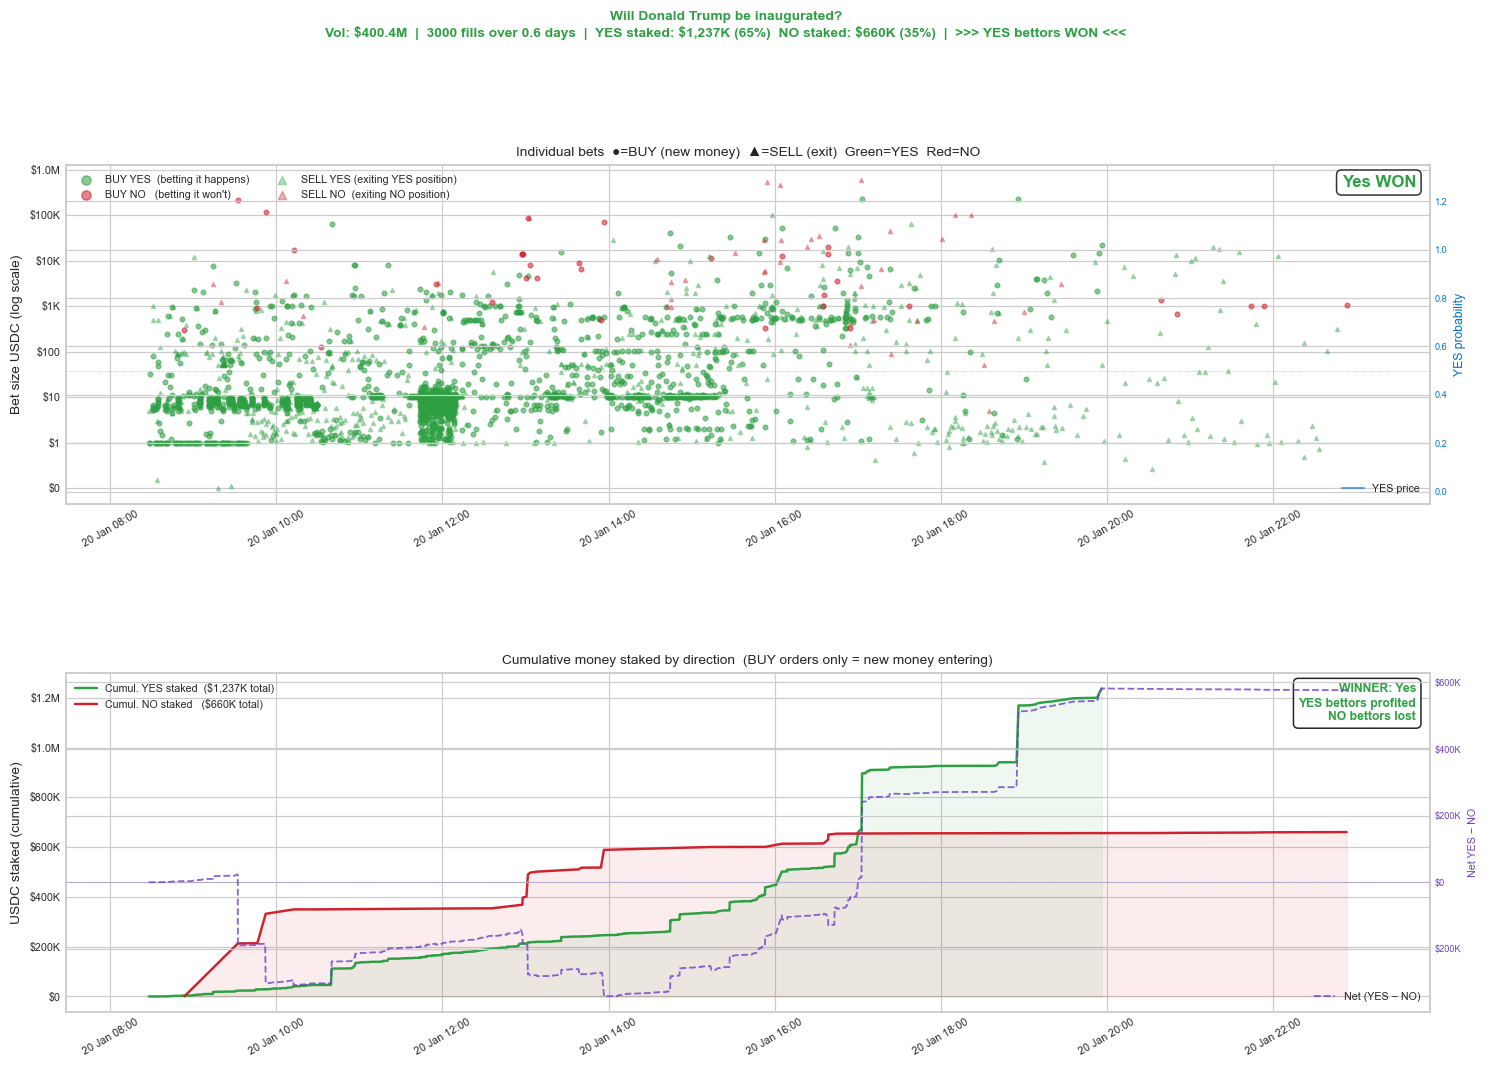

Fetching: Will Nicolae Ciucă win the 2024 Romanian Presidential election?


  3000 fills  span=9.5d
  BUY YES (event happens) : \$  67,305K  (100%)
  BUY NO  (event won't)   : \$     101K  (0%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



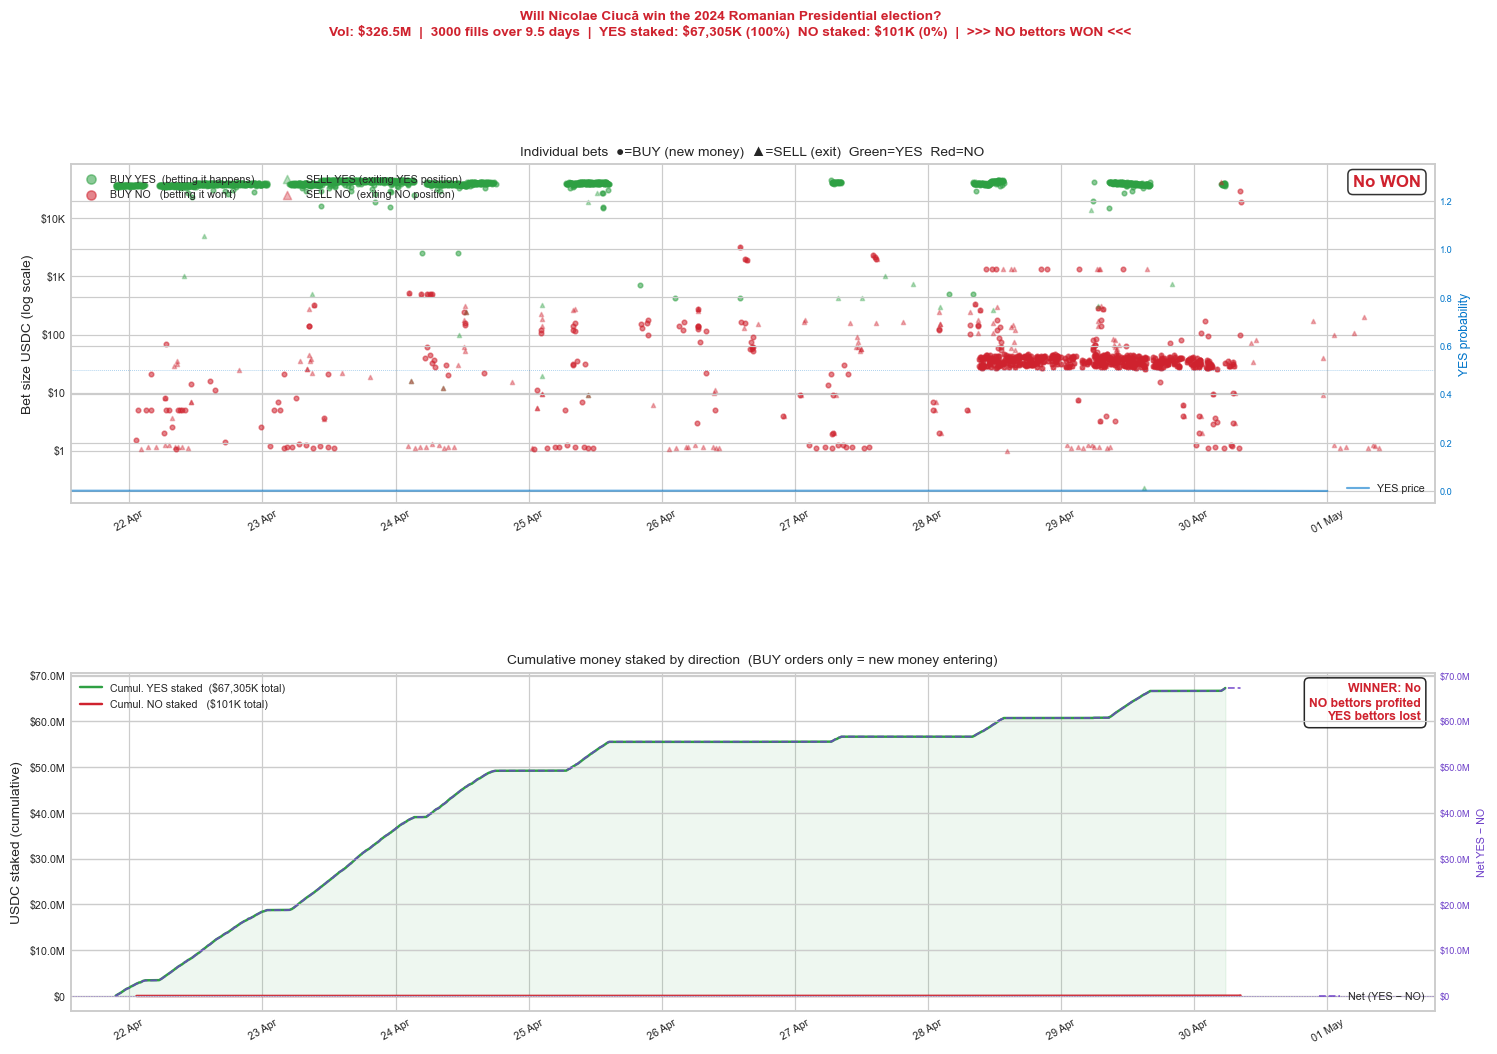

Fetching: Will any other Republican Politician win the 2024 US Presidential


  3000 fills  span=14.3d
  BUY YES (event happens) : \$  21,393K  (99%)
  BUY NO  (event won't)   : \$     236K  (1%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



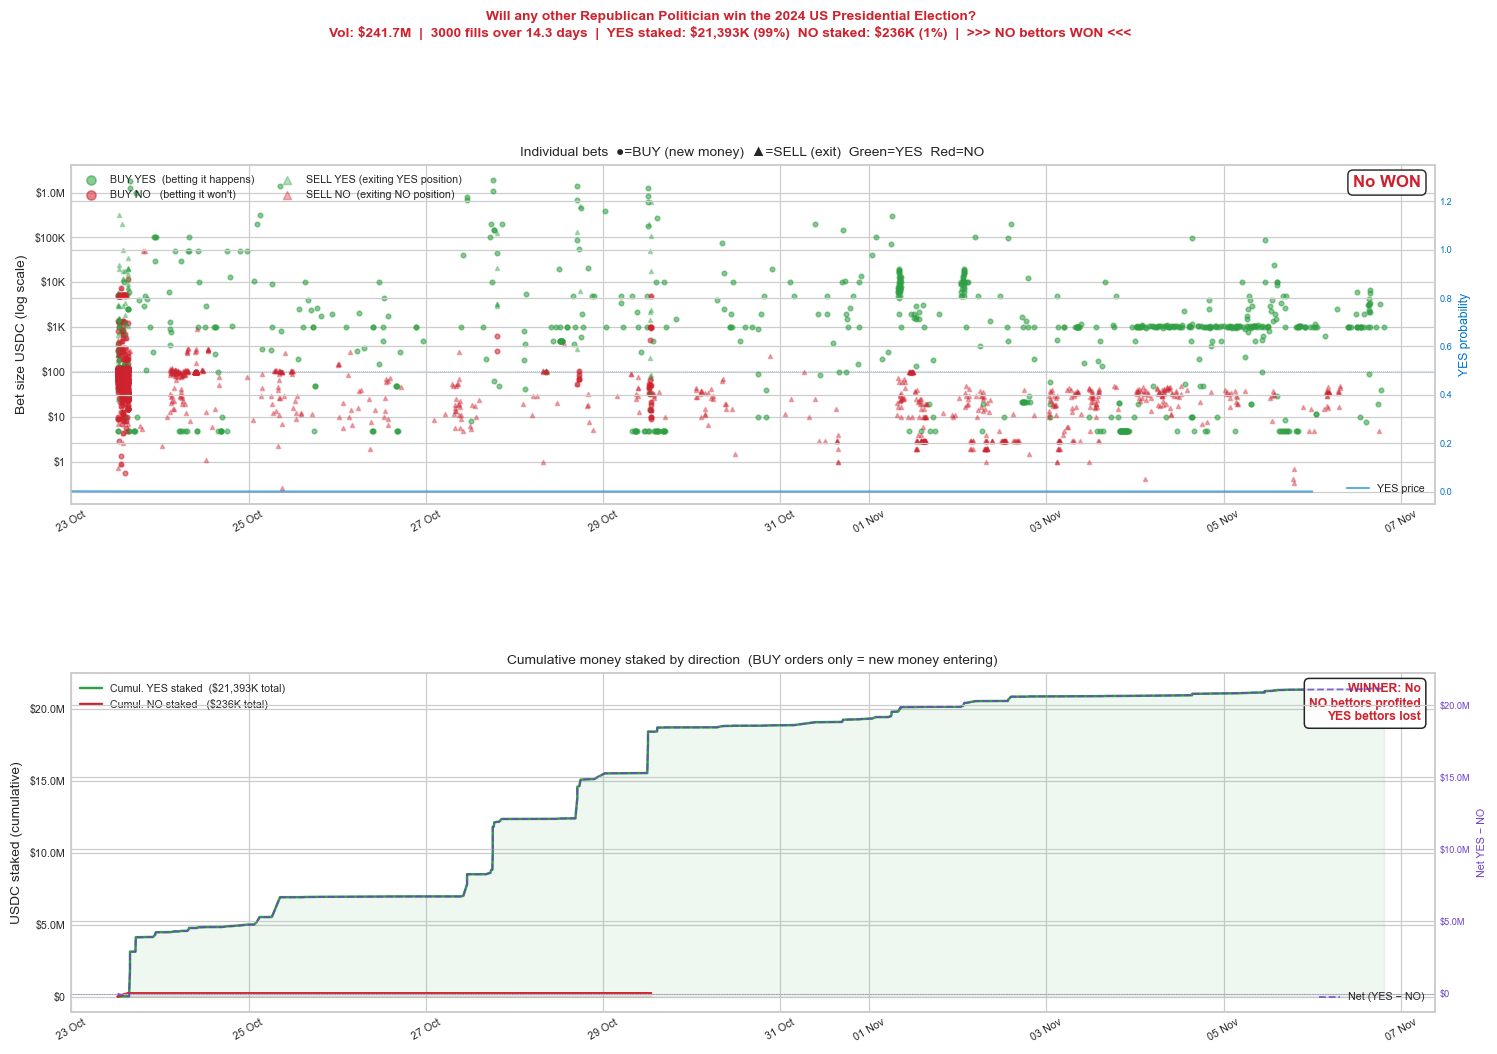

Fetching: Will Michelle Obama win the 2024 US Presidential Election?


  3000 fills  span=23.9d
  BUY YES (event happens) : \$  17,281K  (99%)
  BUY NO  (event won't)   : \$     209K  (1%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



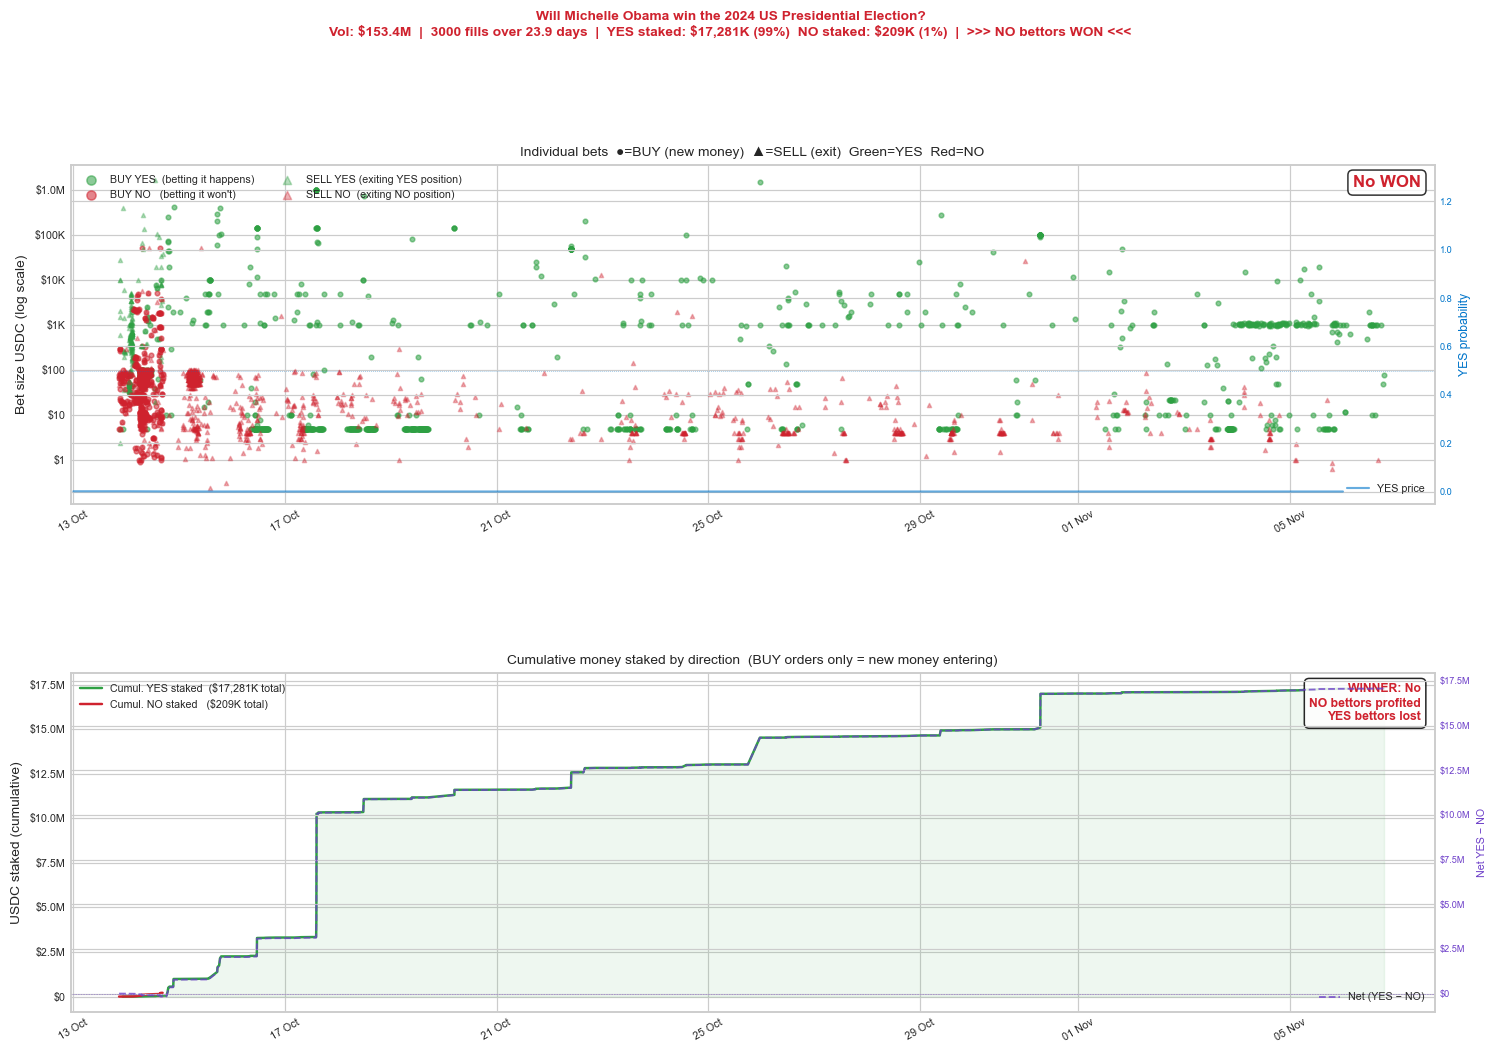

Fetching: Will Zohran Mamdani win the 2025 NYC mayoral election?


  3000 fills  span=0.2d
  BUY YES (event happens) : \$   5,576K  (56%)
  BUY NO  (event won't)   : \$   4,378K  (44%)
  Resolution → Yes  |  YES bettors WON  |  NO bettors LOST



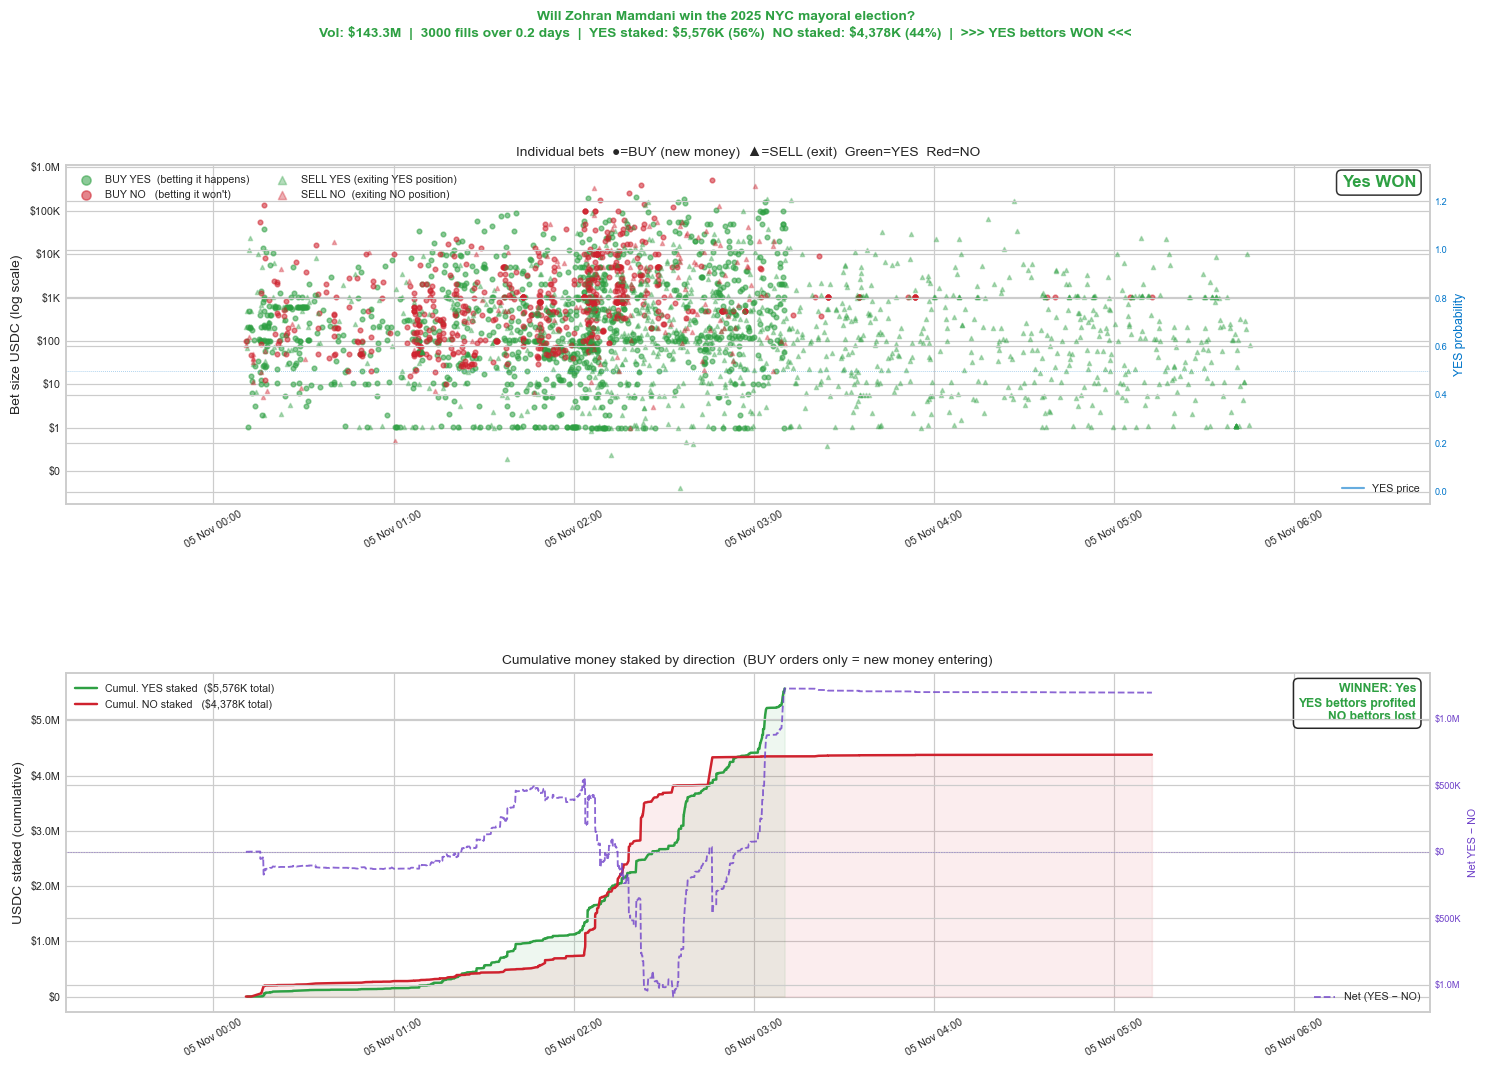

Fetching: Will Robert F. Kennedy Jr. win the 2024 US Presidential Election?


  3000 fills  span=23.0d
  BUY YES (event happens) : \$   2,571K  (95%)
  BUY NO  (event won't)   : \$     133K  (5%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



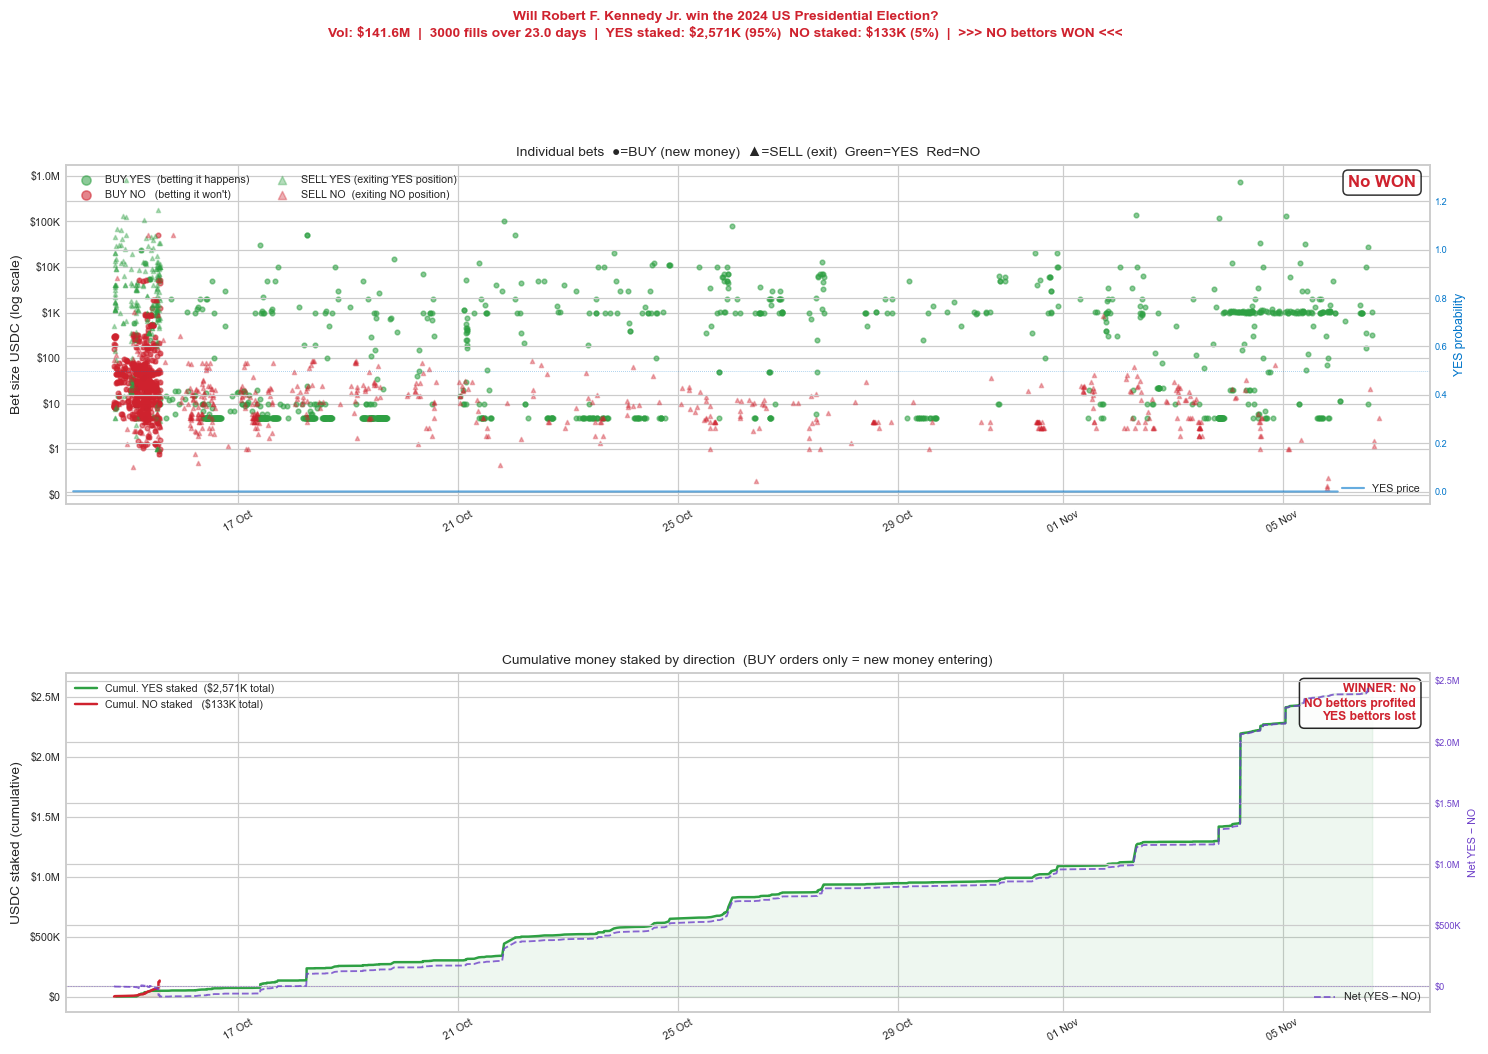

Fetching: Will Trump nominate Judy Shelton as the next Fed chair?


  3000 fills  span=0.6d
  BUY YES (event happens) : \$  10,539K  (54%)
  BUY NO  (event won't)   : \$   8,978K  (46%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



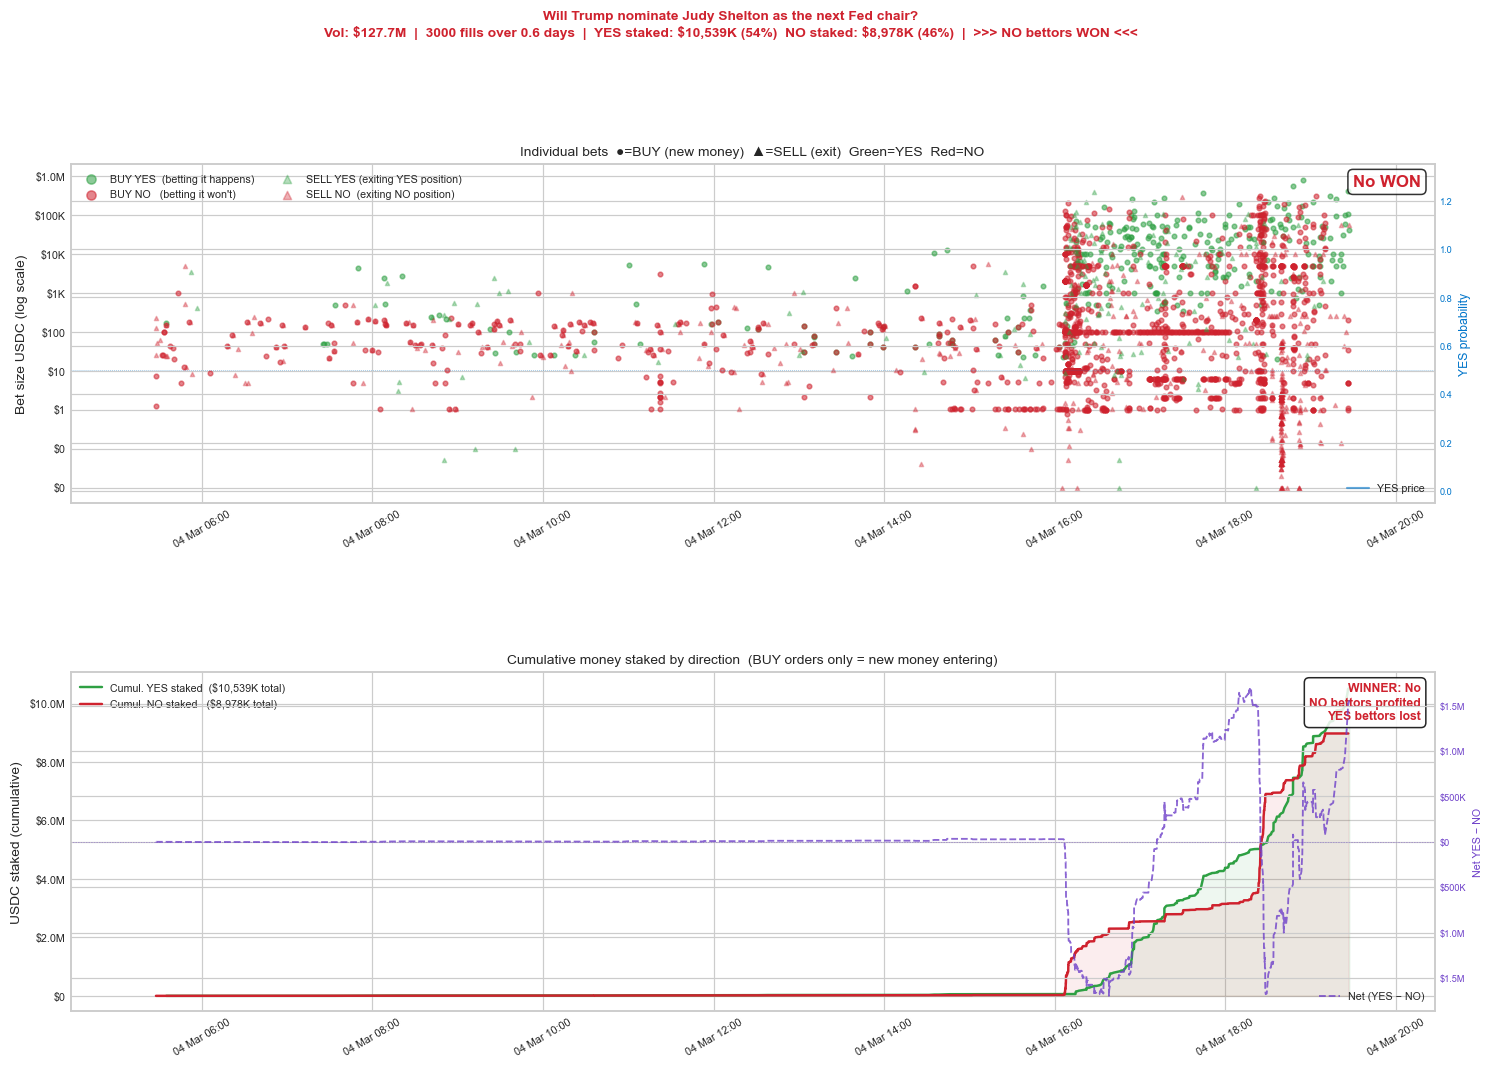

Fetching: Will any other Democratic Politician win the 2024 US Presidential


  3000 fills  span=23.3d
  BUY YES (event happens) : \$   5,569K  (93%)
  BUY NO  (event won't)   : \$     441K  (7%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



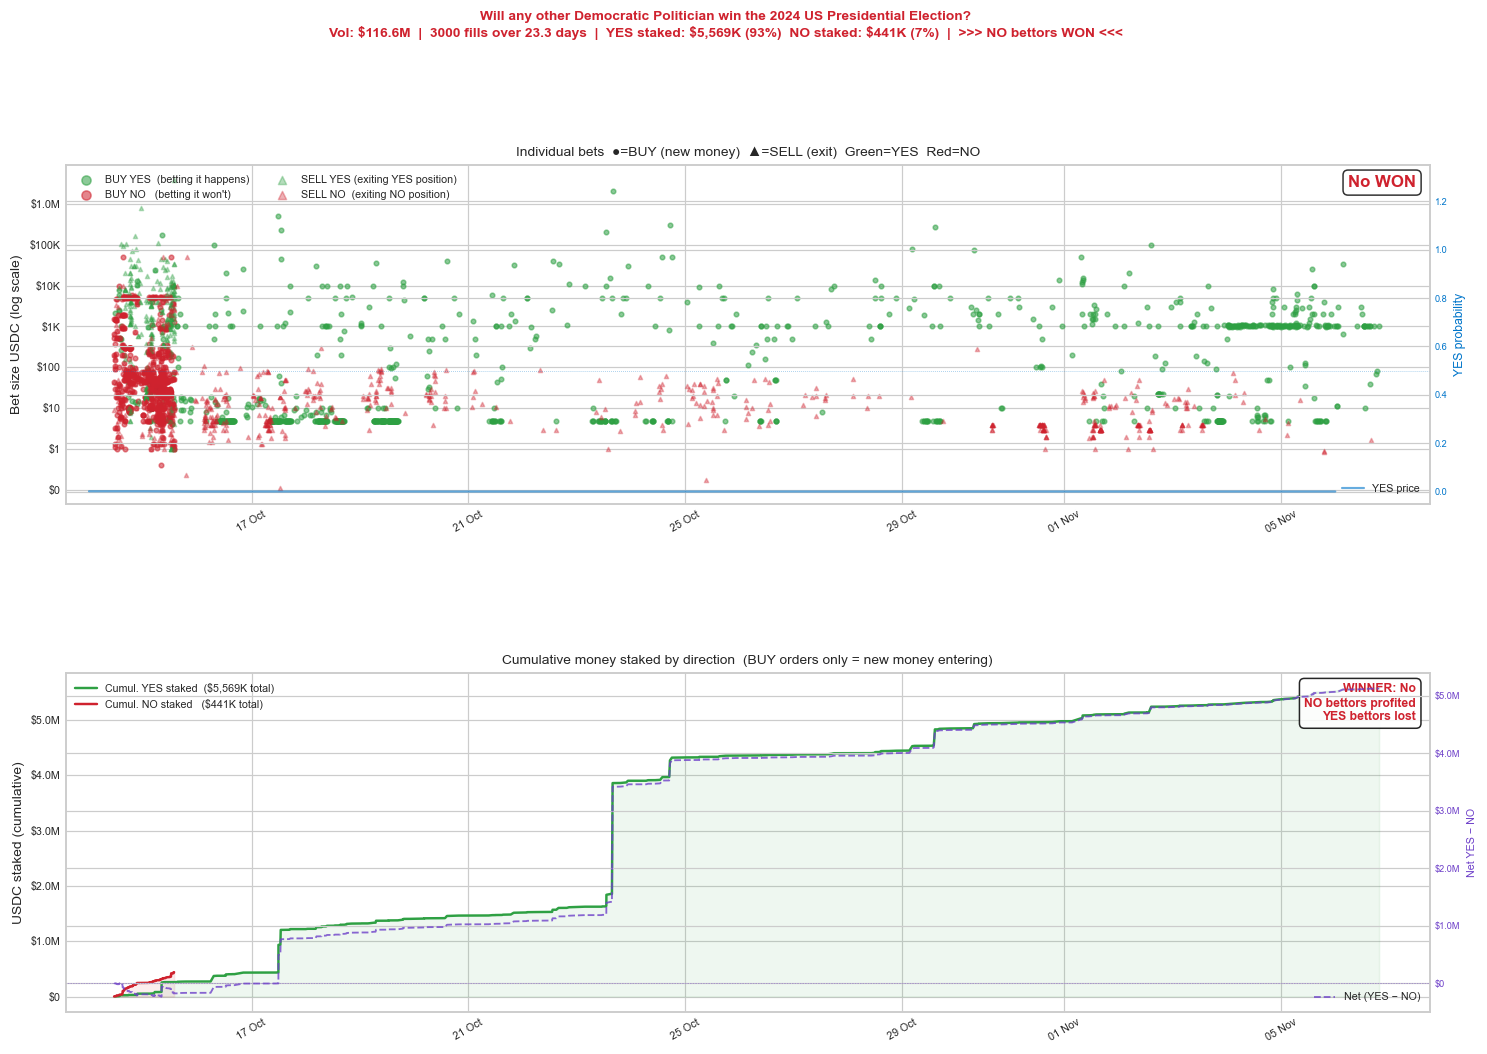

Fetching: Will Frances Fitzgerald win the Irish Presidential Election?


  3000 fills  span=181.7d
  BUY YES (event happens) : \$ 114,580K  (100%)
  BUY NO  (event won't)   : \$     101K  (0%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



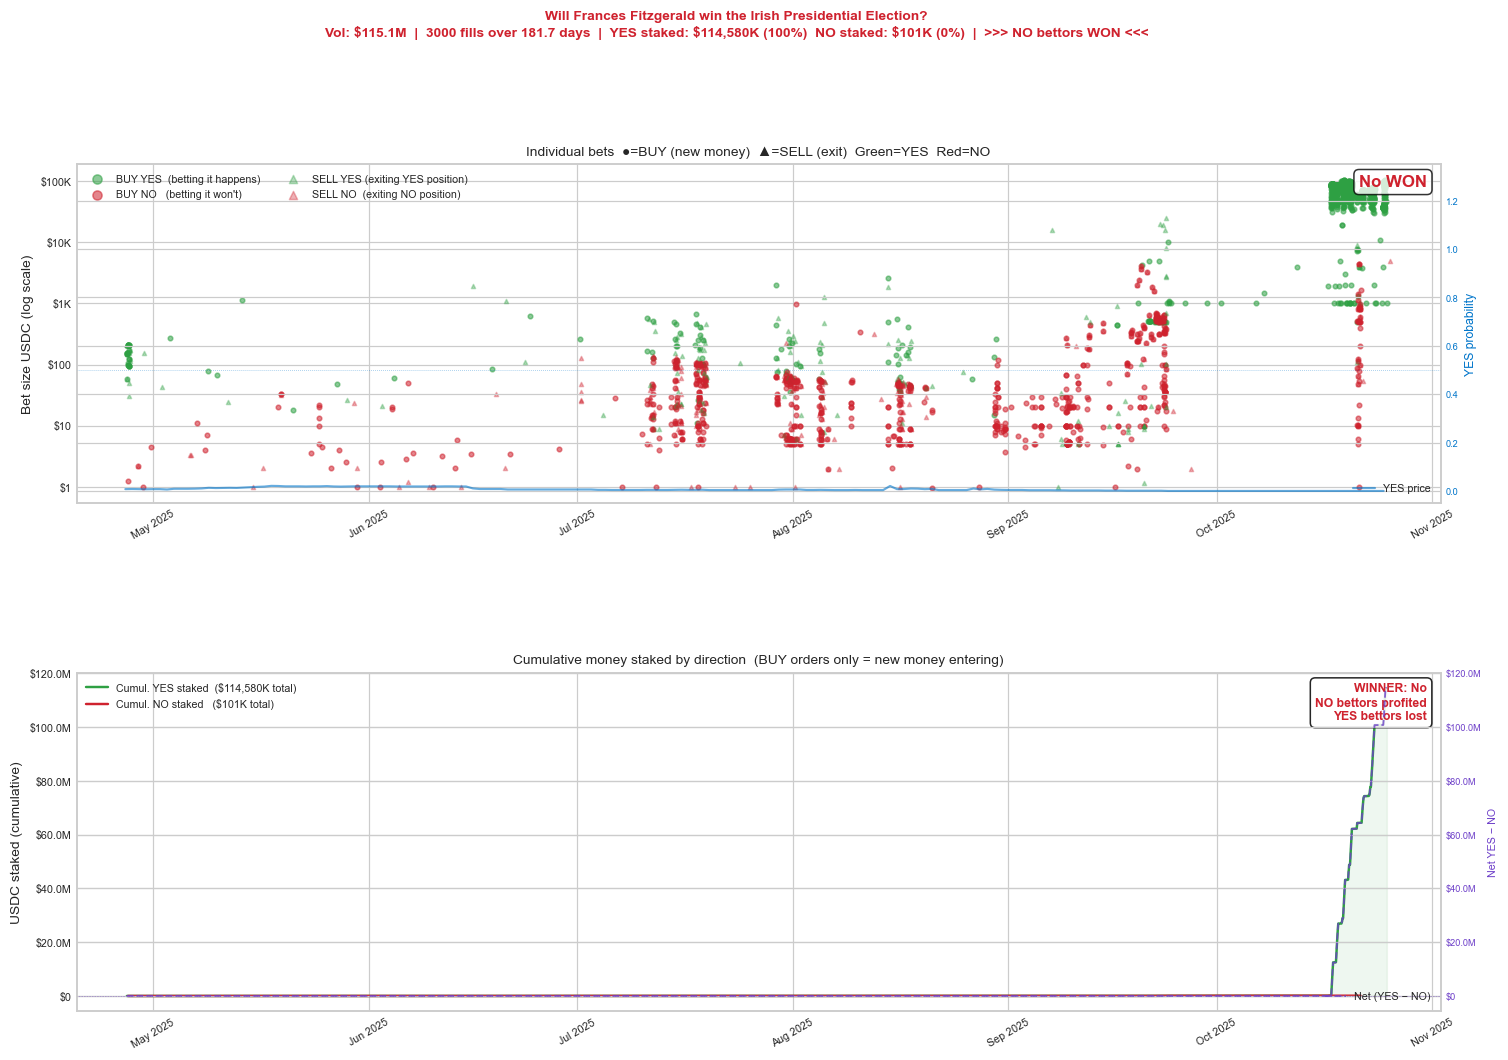

Fetching: Will Nikki Haley win the 2024 US Presidential Election?


  3000 fills  span=27.4d
  BUY YES (event happens) : \$   2,238K  (89%)
  BUY NO  (event won't)   : \$     263K  (11%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



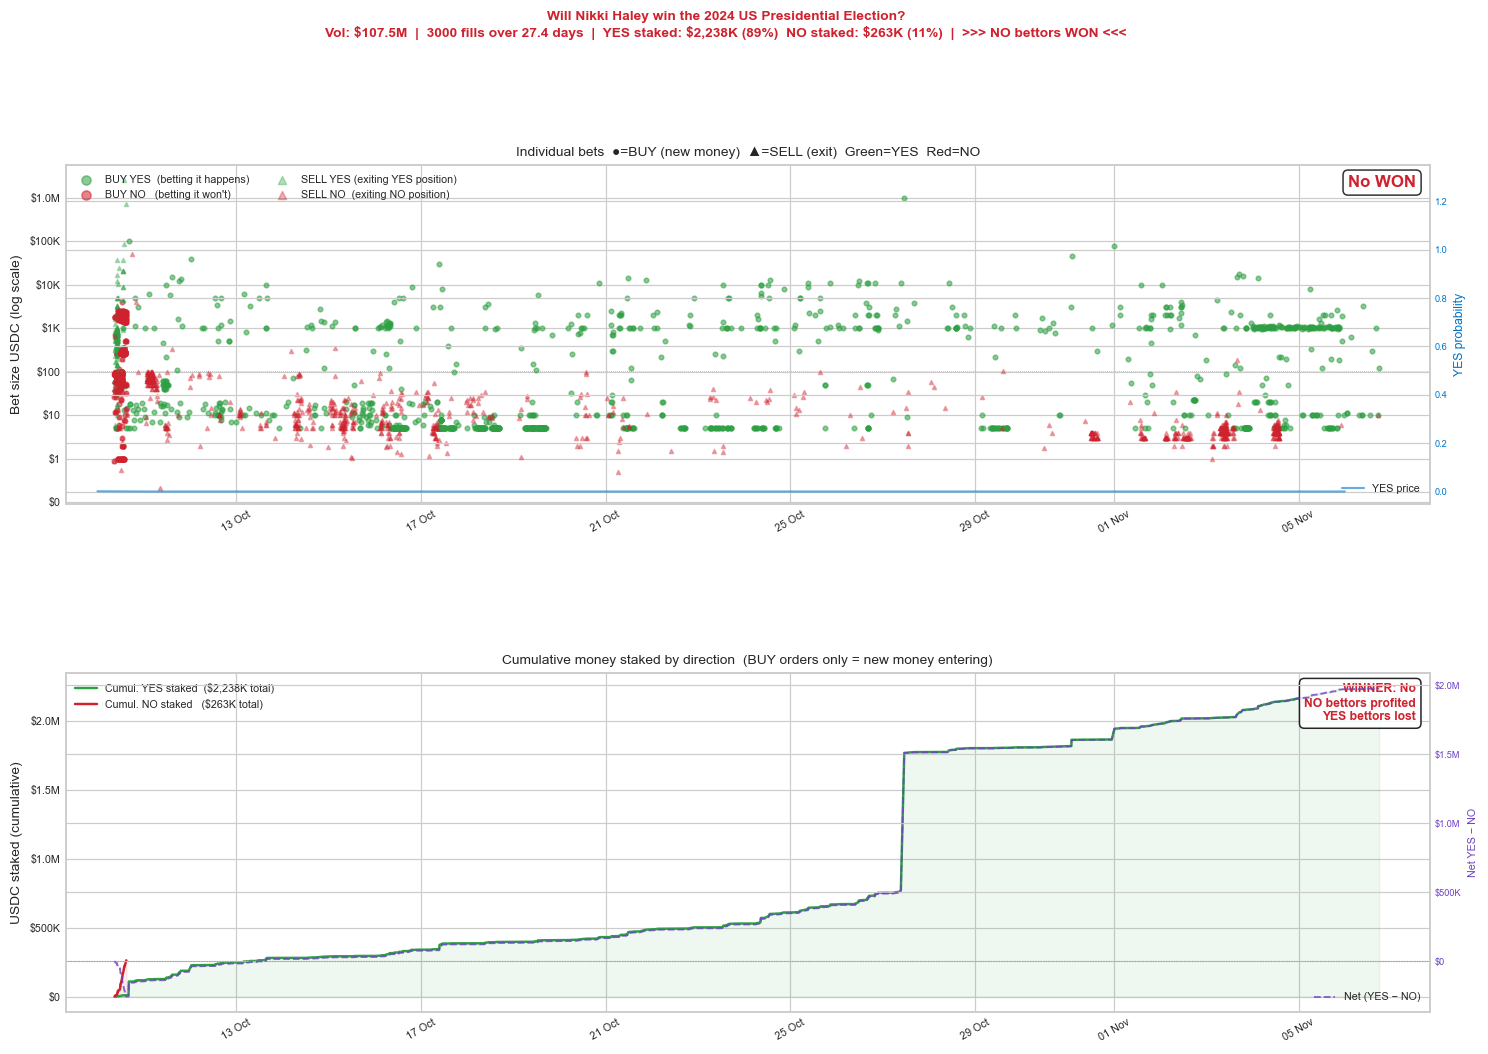

Fetching: Will Hillary Clinton win the 2024 US Presidential Election?


  3000 fills  span=29.5d
  BUY YES (event happens) : \$   5,666K  (85%)
  BUY NO  (event won't)   : \$   1,038K  (15%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



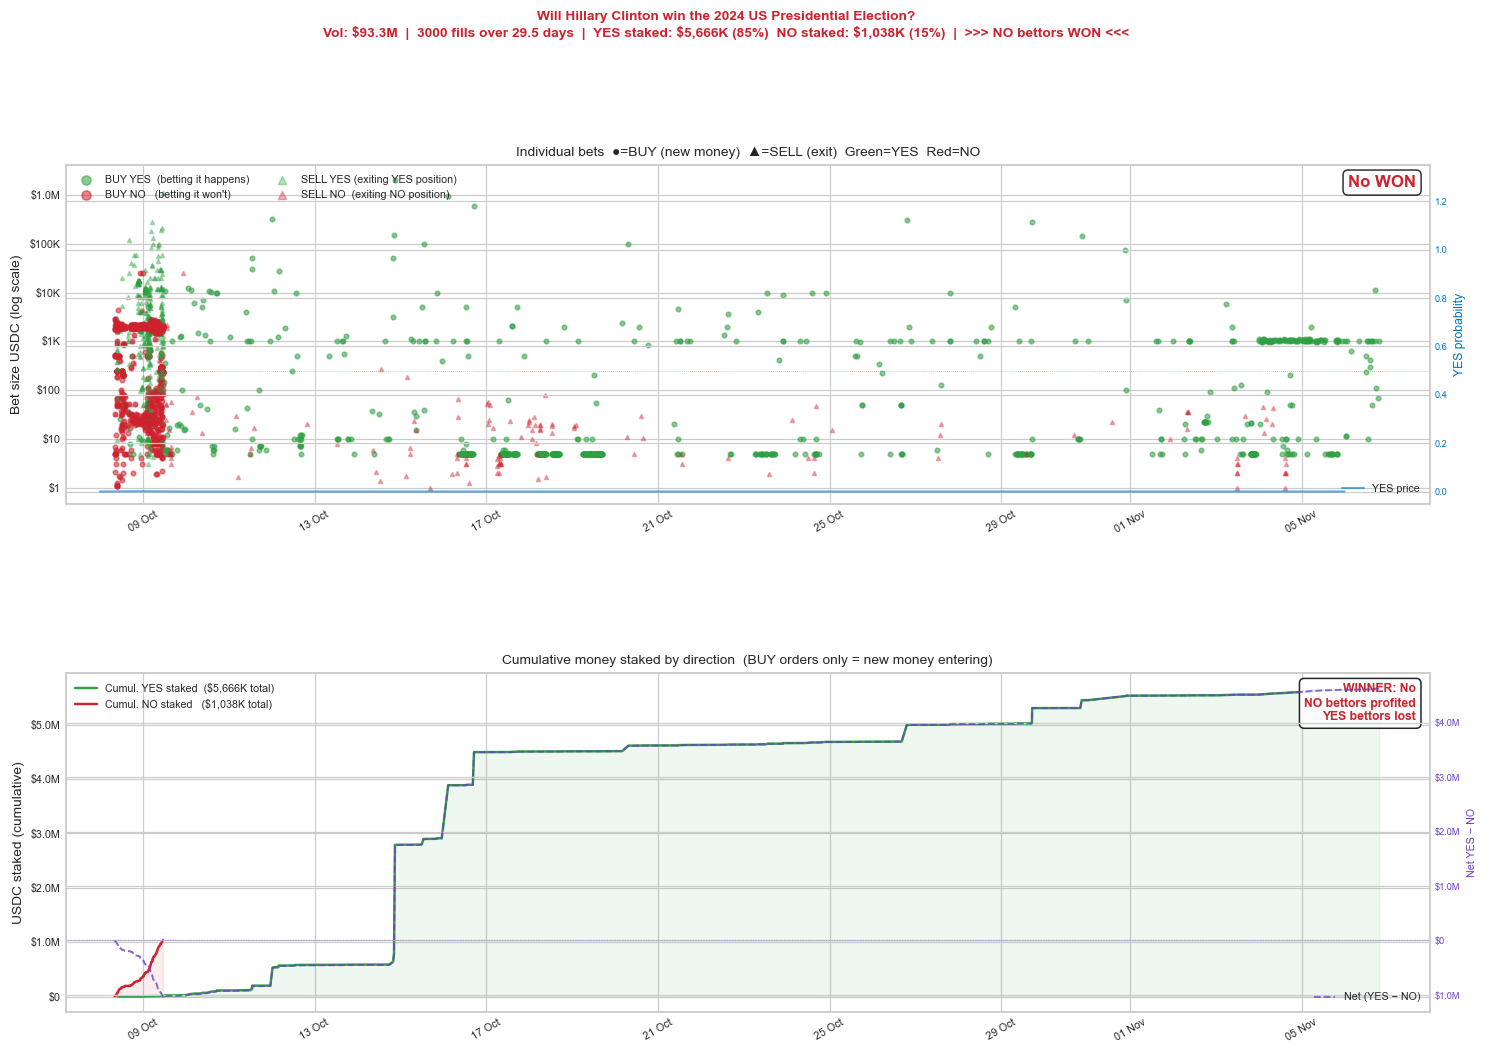

Fetching: Will Gavin Newsom be D-nom for VP on Election Day?


  3000 fills  span=36.7d
  BUY YES (event happens) : \$  88,245K  (100%)
  BUY NO  (event won't)   : \$     326K  (0%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



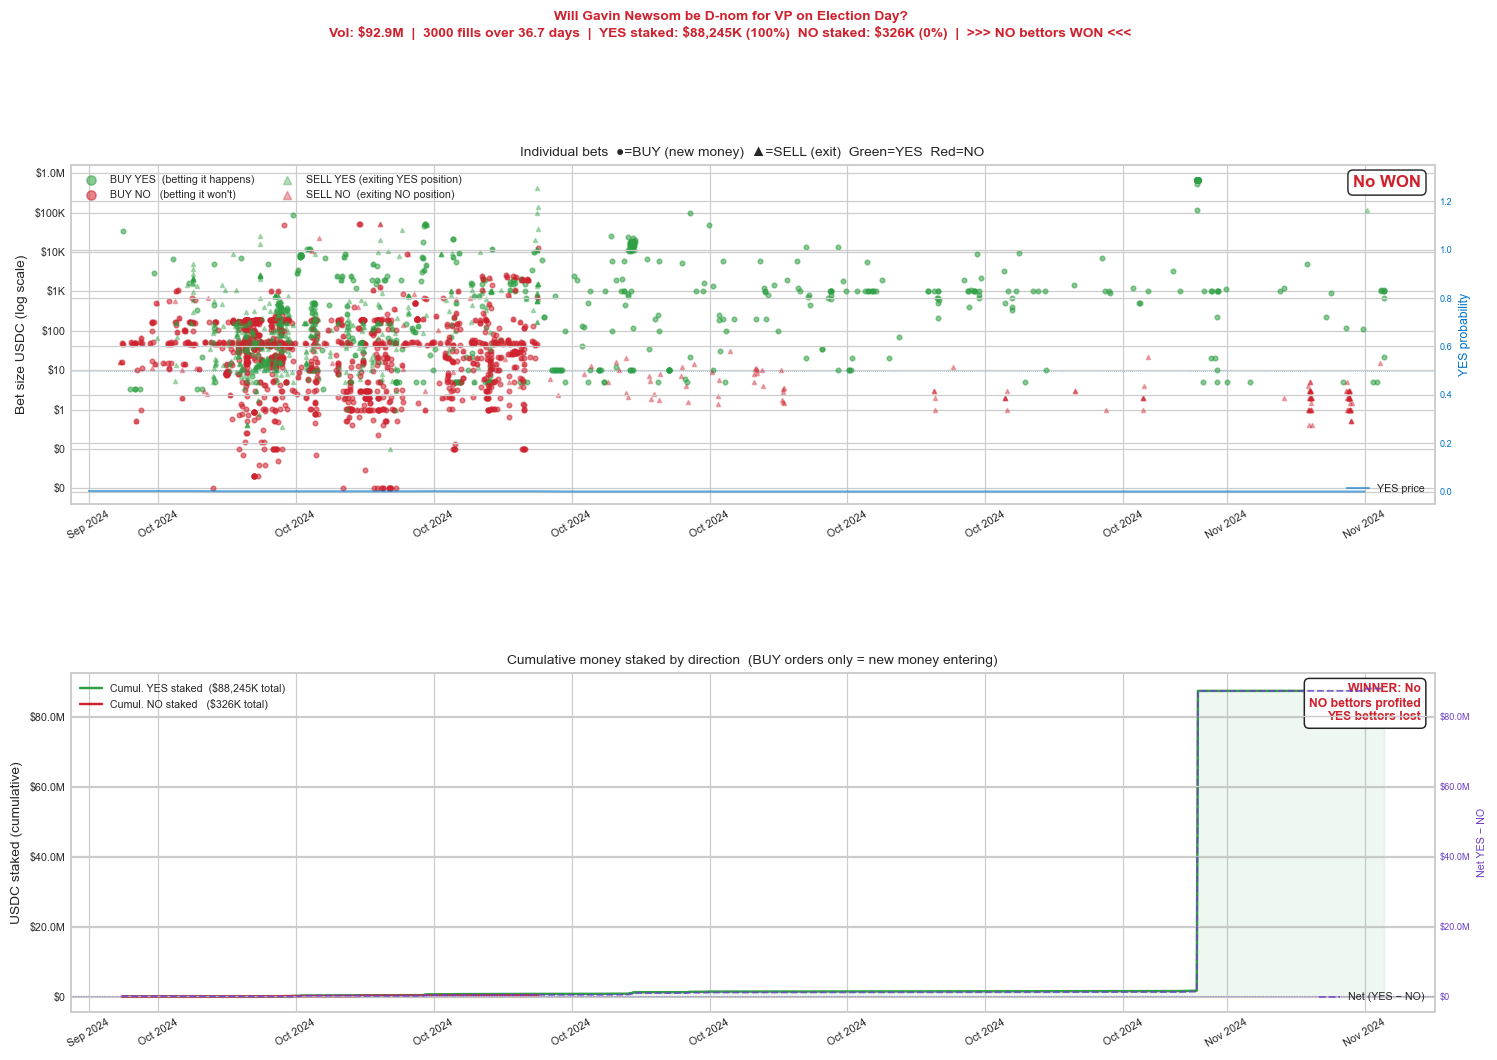

Fetching: Will Trump release the Epstein files by December 19?


  3000 fills  span=1.6d
  BUY YES (event happens) : \$   3,391K  (18%)
  BUY NO  (event won't)   : \$  14,942K  (82%)
  Resolution → Yes  |  YES bettors WON  |  NO bettors LOST



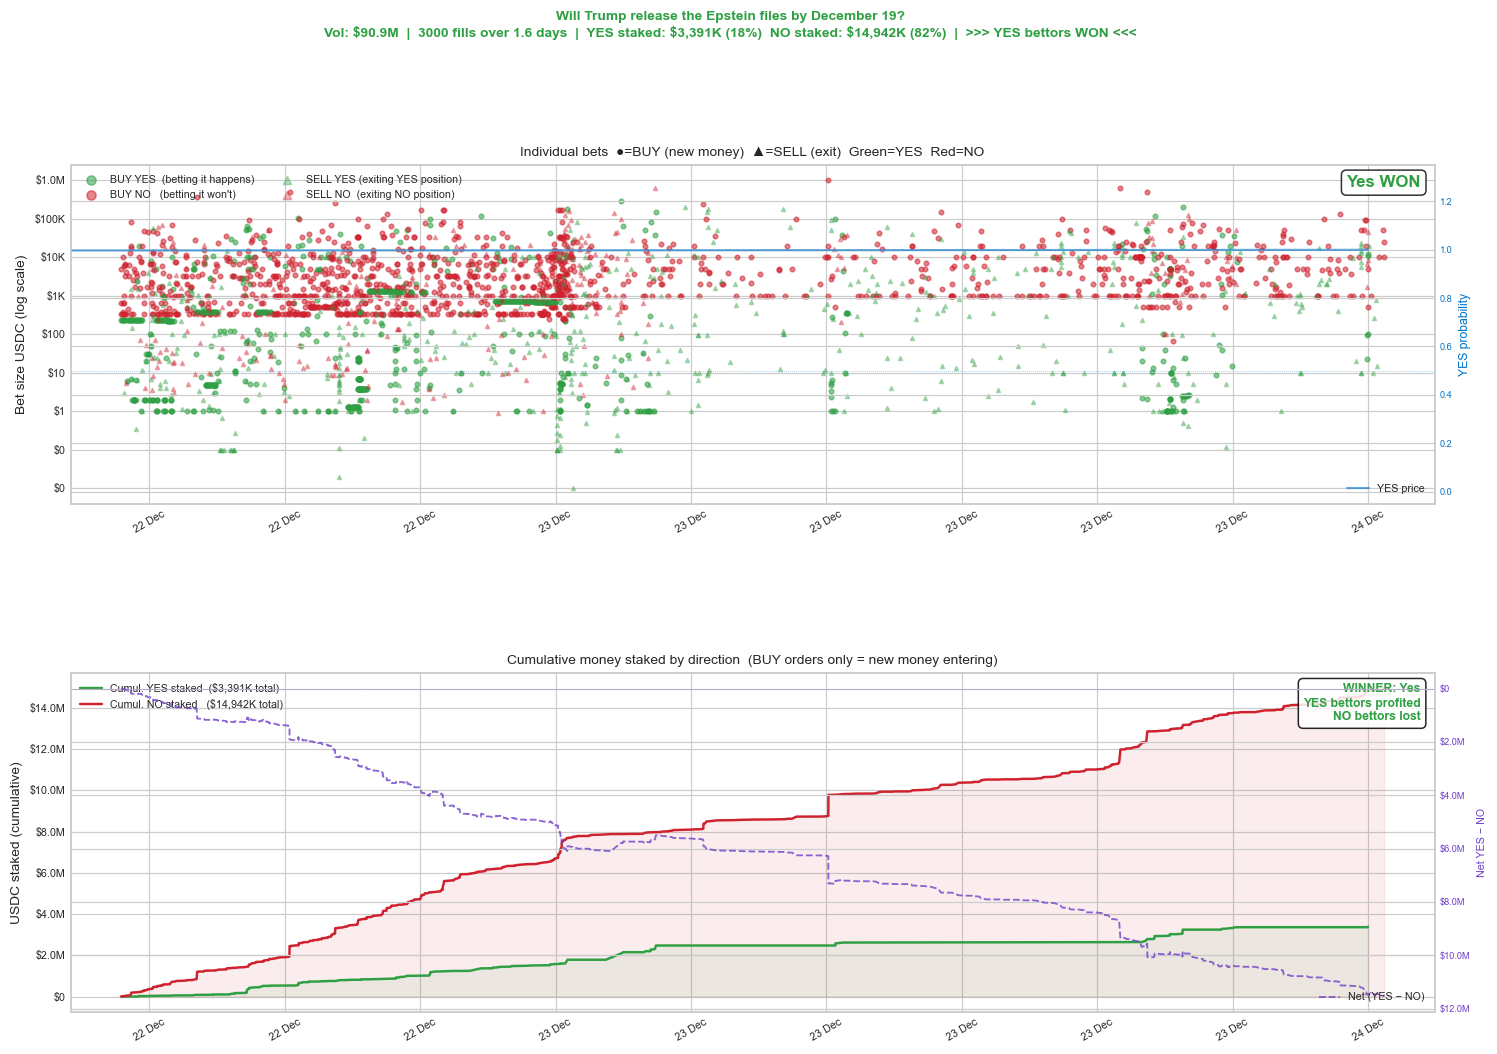

Fetching: Will Lee Jae-myung be elected the next president of South Korea?


  3000 fills  span=0.5d
  BUY YES (event happens) : \$   4,340K  (43%)
  BUY NO  (event won't)   : \$   5,638K  (57%)
  Resolution → Yes  |  YES bettors WON  |  NO bettors LOST



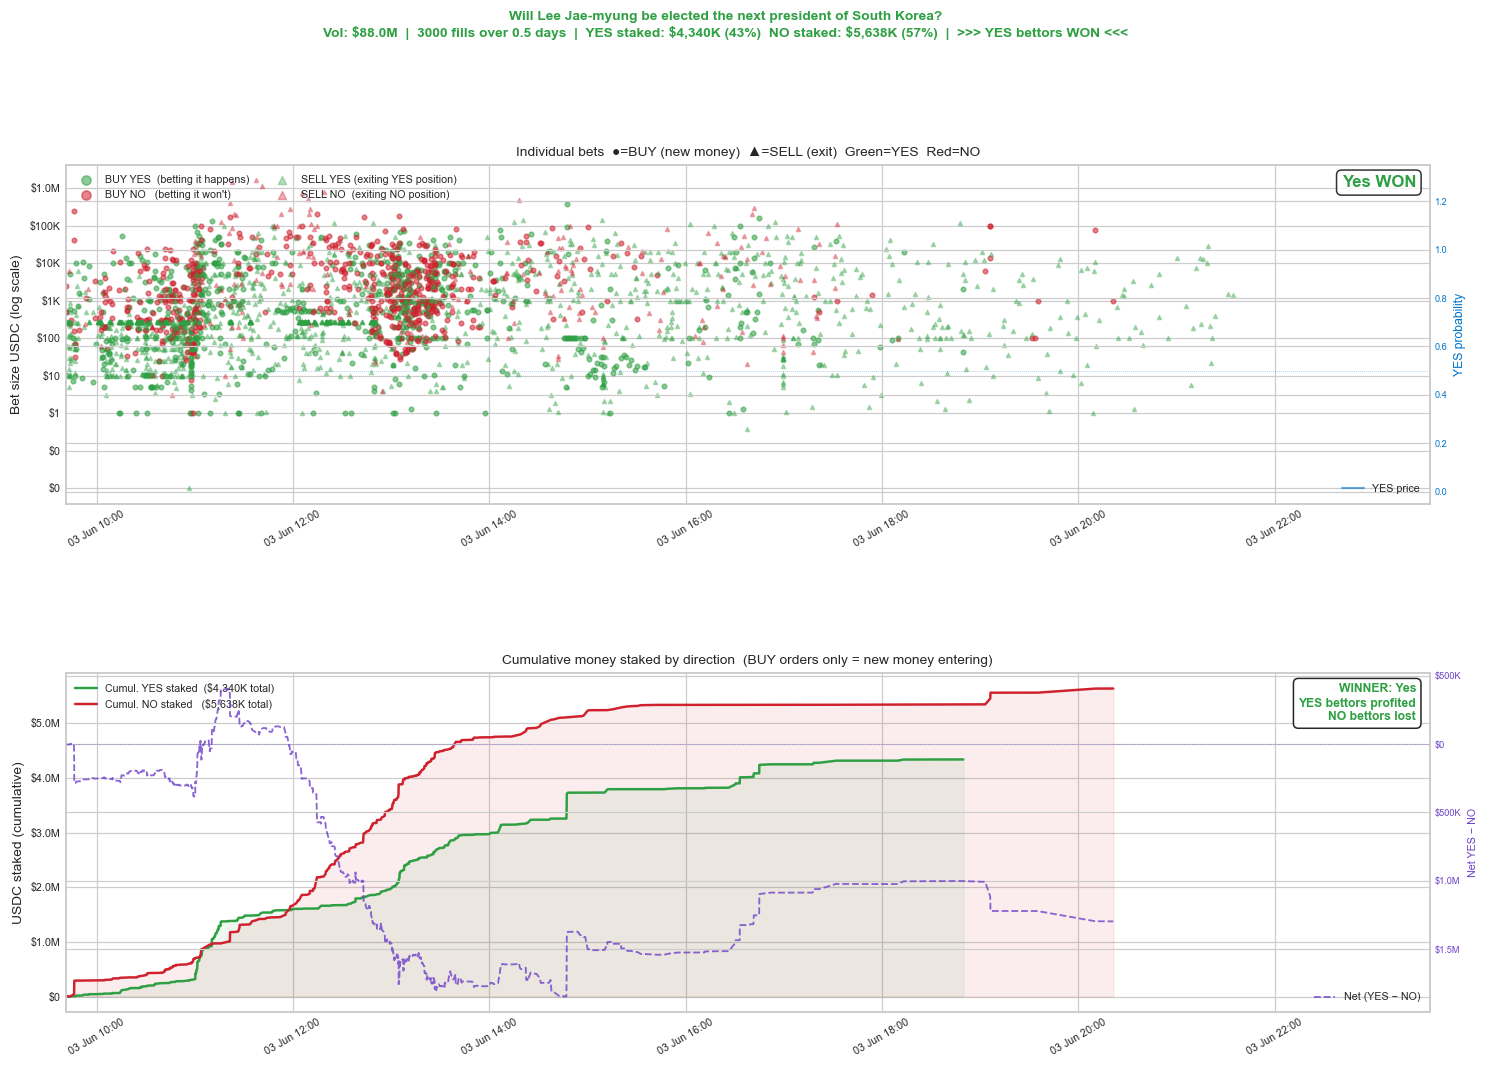

Fetching: Will Hunor Kelemen win the Romanian presidential election?


  3000 fills  span=87.1d
  BUY YES (event happens) : \$  80,478K  (100%)
  BUY NO  (event won't)   : \$      63K  (0%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



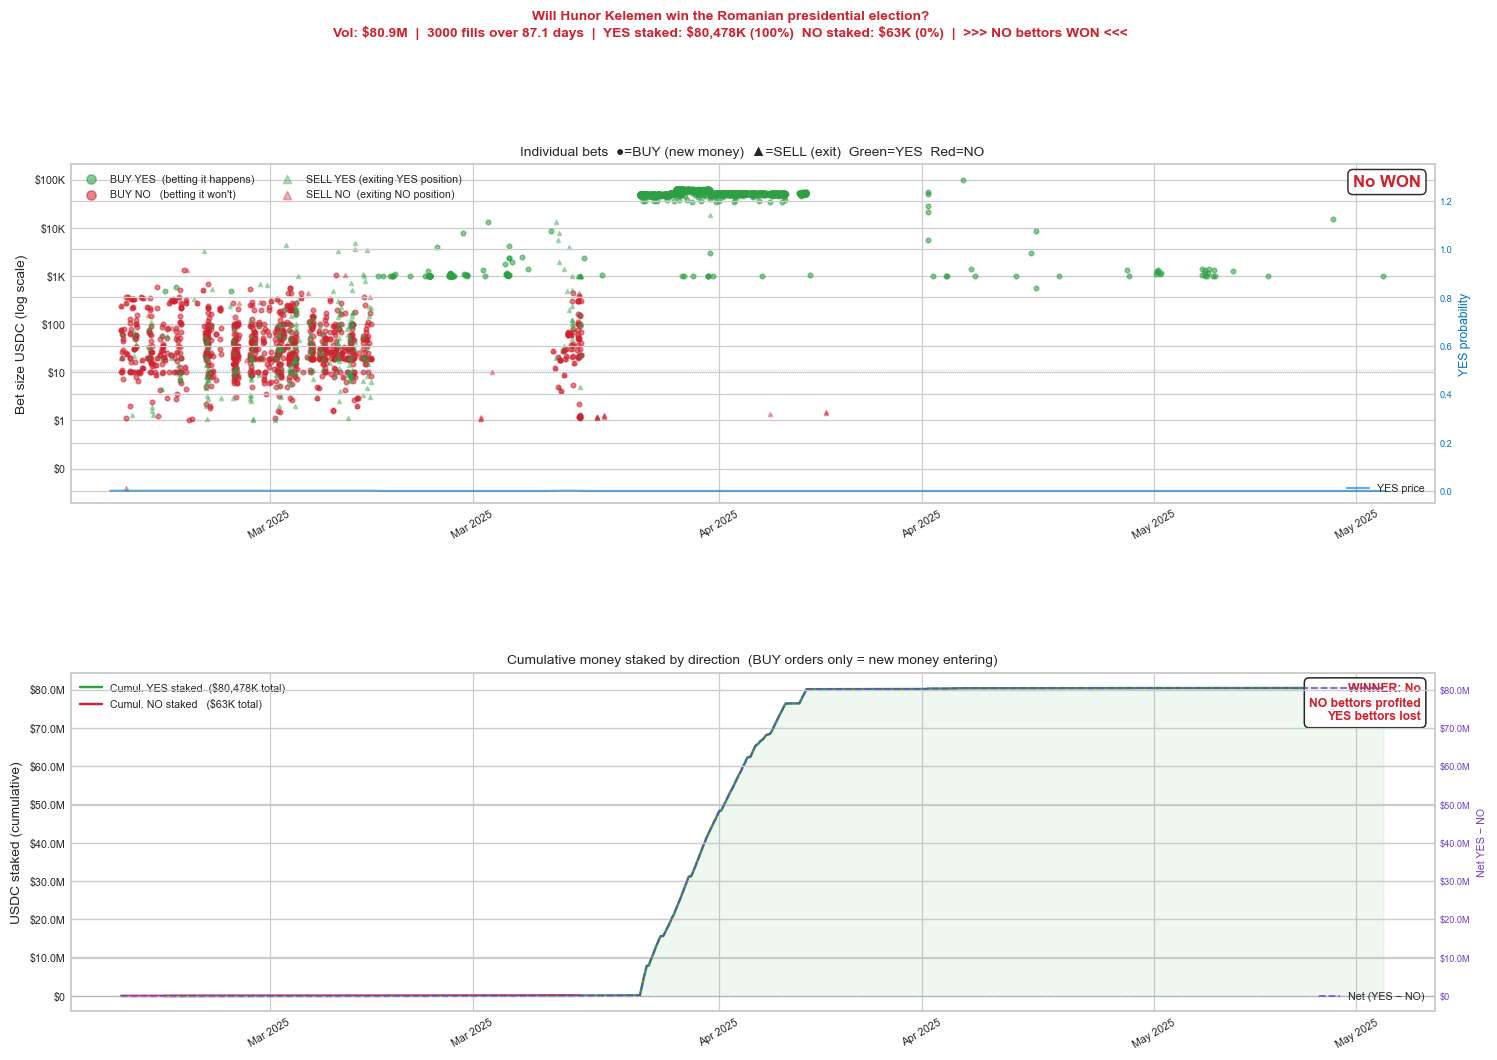

Fetching: Will Trump launch a coin before the election?


  3000 fills  span=0.5d
  BUY YES (event happens) : \$   6,036K  (29%)
  BUY NO  (event won't)   : \$  14,742K  (71%)
  Resolution → Yes  |  YES bettors WON  |  NO bettors LOST



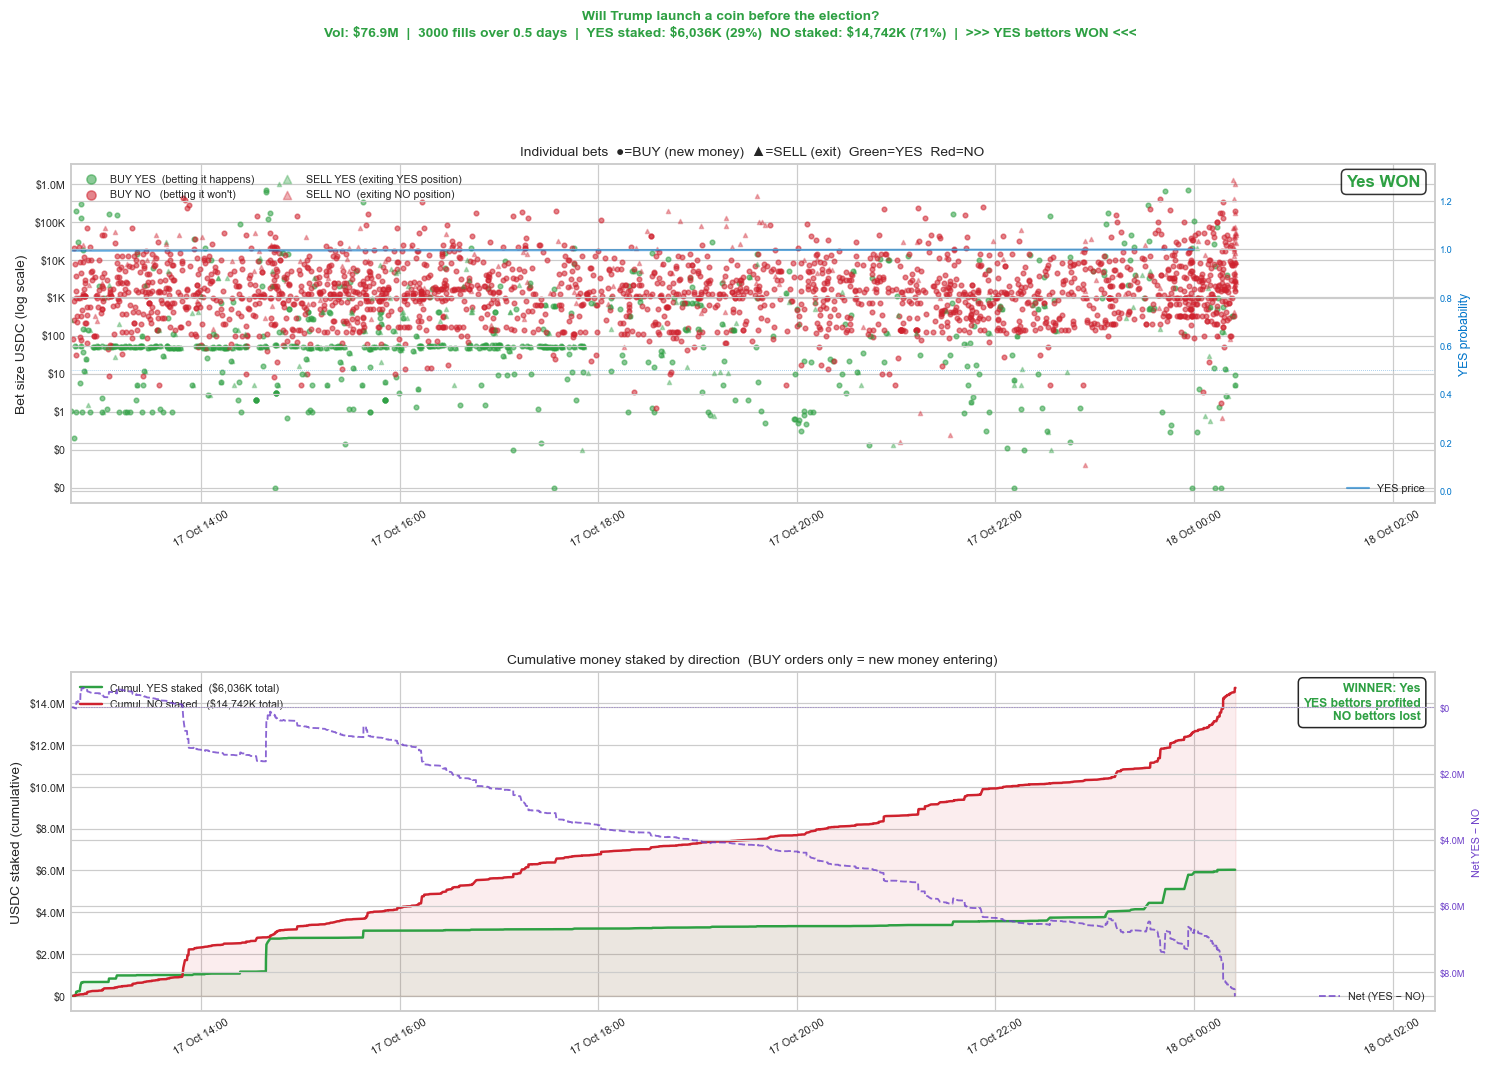

Fetching: Will Kim Moon-soo be elected the next president of South Korea?


  3000 fills  span=0.5d
  BUY YES (event happens) : \$  16,923K  (85%)
  BUY NO  (event won't)   : \$   3,008K  (15%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



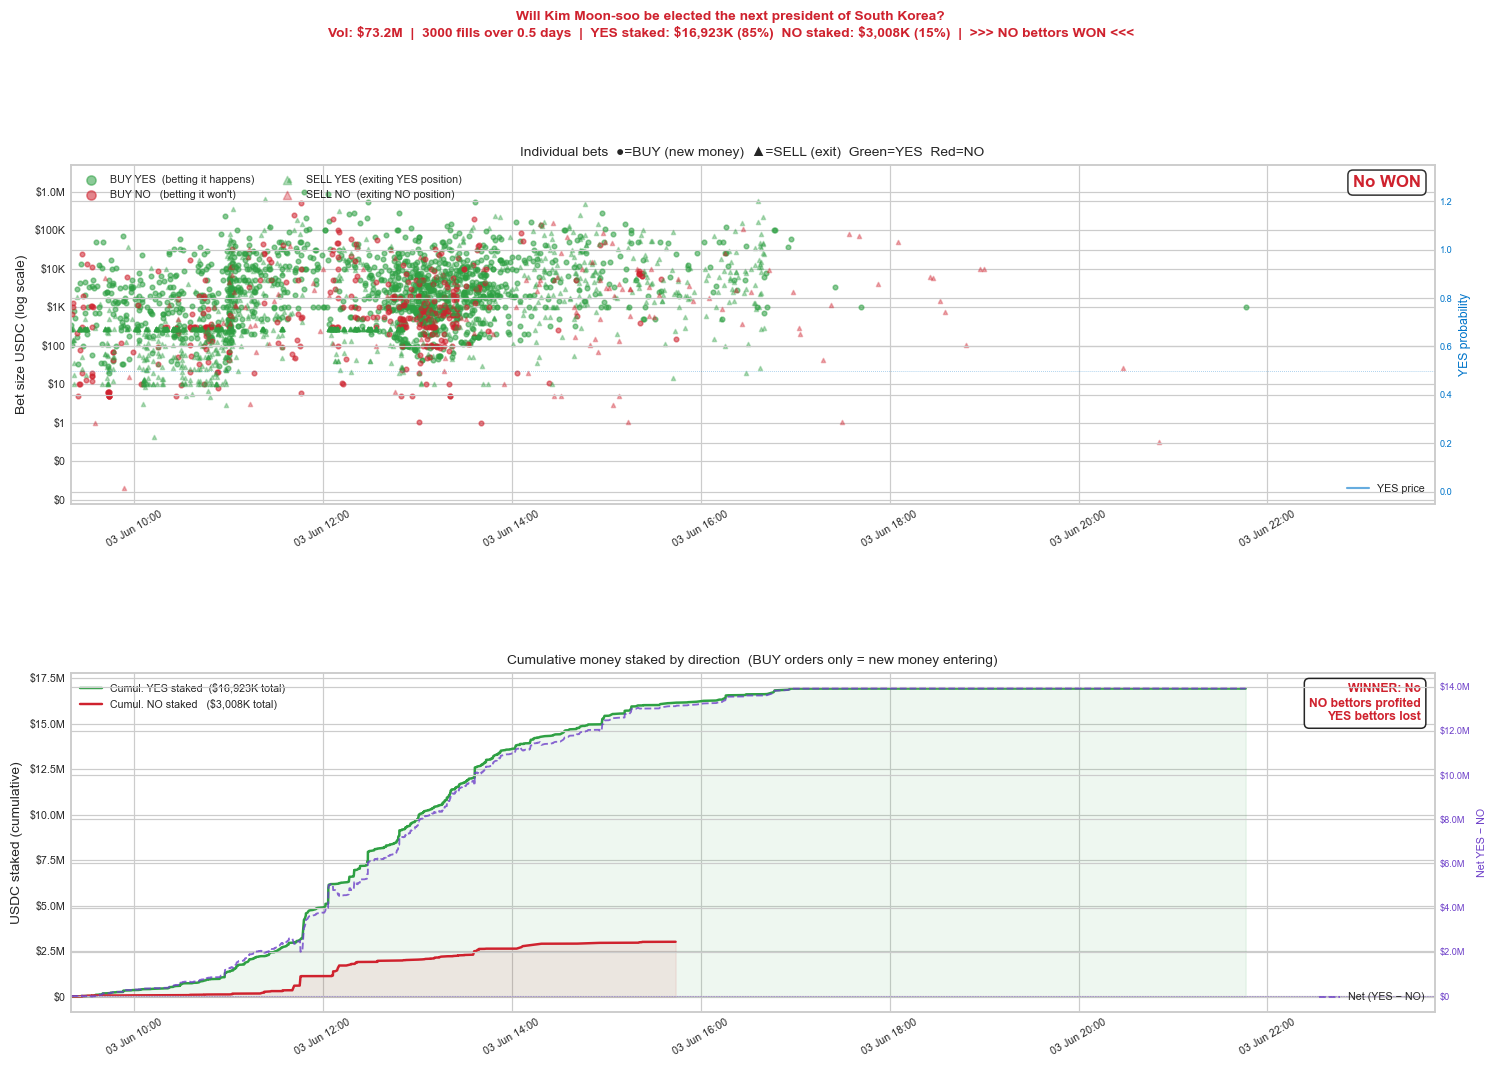

Fetching: Will Kamala Harris be inaugurated?


  3000 fills  span=2.0d
  BUY YES (event happens) : \$     661K  (62%)
  BUY NO  (event won't)   : \$     403K  (38%)
  Resolution →  No  |  NO bettors WON  |  YES bettors LOST



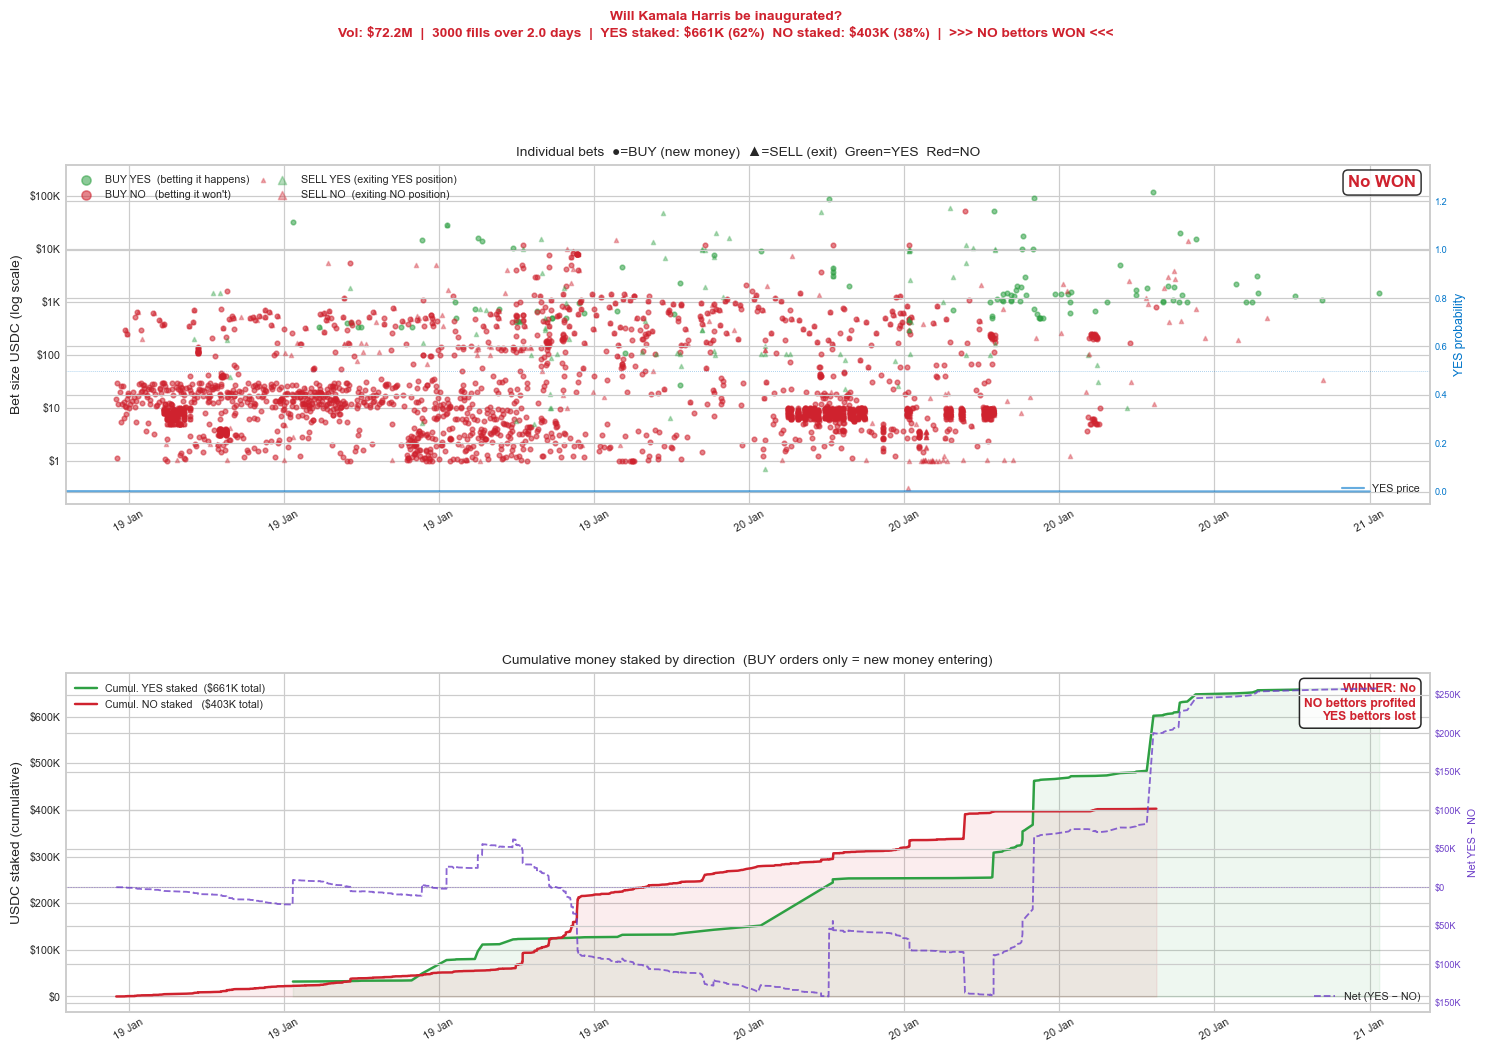

In [3]:
for row in markets.sort('volume_usdc', descending=True).iter_rows(named=True):
    slug       = row['slug']
    question   = row['question']
    resolution = row['resolution']   # 'Yes' or 'No'
    total_vol  = float(row['volume_usdc'] or 0)
    cond_id    = row['condition_id']

    print(f'Fetching: {question[:65]}')
    ph = load_ph(slug)
    tr = fetch_all_trades(cond_id)

    if tr.is_empty():
        print('  No data — skipped\n'); continue

    # ── Segment by direction and action ──────────────────────────────────
    yes_buy  = tr.filter((pl.col('side') == 'BUY')  & (pl.col('outcome') == 'Yes'))
    no_buy   = tr.filter((pl.col('side') == 'BUY')  & (pl.col('outcome') == 'No'))
    yes_sell = tr.filter((pl.col('side') == 'SELL') & (pl.col('outcome') == 'Yes'))
    no_sell  = tr.filter((pl.col('side') == 'SELL') & (pl.col('outcome') == 'No'))

    yes_buy_vol  = float(yes_buy['size'].sum()  or 0)
    no_buy_vol   = float(no_buy['size'].sum()   or 0)
    yes_sell_vol = float(yes_sell['size'].sum() or 0)
    no_sell_vol  = float(no_sell['size'].sum()  or 0)
    total_staked = yes_buy_vol + no_buy_vol

    yes_pct = 100 * yes_buy_vol / total_staked if total_staked else 0
    no_pct  = 100 - yes_pct

    # ── Who won? ─────────────────────────────────────────────────────────
    yes_won     = (resolution == 'Yes')
    winner_side = 'YES bettors' if yes_won else 'NO bettors'
    loser_side  = 'NO bettors'  if yes_won else 'YES bettors'
    winner_vol  = yes_buy_vol   if yes_won else no_buy_vol
    loser_vol   = no_buy_vol    if yes_won else yes_buy_vol
    c_winner    = C_YES if yes_won else C_NO
    c_loser     = C_NO  if yes_won else C_YES

    # ── Time window ──────────────────────────────────────────────────────
    ts_min = int(tr['timestamp'].min())
    ts_max = int(tr['timestamp'].max())
    span_d = (ts_max - ts_min) / 86400
    pad    = timedelta(seconds=max((ts_max - ts_min) * 0.04, 3600))
    xlim   = (datetime.fromtimestamp(ts_min) - pad,
              datetime.fromtimestamp(ts_max) + pad)
    date_fmt = mdates.DateFormatter(
        '%d %b %H:%M' if span_d < 1 else '%d %b' if span_d < 30 else '%b %Y')

    ph_clip = ph.filter(
        (pl.col('timestamp') >= ts_min - 86400) &
        (pl.col('timestamp') <= ts_max + 86400)
    ) if not ph.is_empty() else ph

    # ── Console summary ───────────────────────────────────────────────────
    print(f'  {len(tr)} fills  span={span_d:.1f}d')
    print(f'  BUY YES (event happens) : \${yes_buy_vol/1e3:>8,.0f}K  ({yes_pct:.0f}%)')
    print(f'  BUY NO  (event won\'t)   : \${no_buy_vol/1e3:>8,.0f}K  ({no_pct:.0f}%)')
    print(f'  Resolution → {resolution:>3}  |  {winner_side} WON  |  '
          f'{loser_side} LOST')
    print()

    # ── Figure ────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10),
                                    gridspec_kw={'hspace': 0.5})

    # Winner banner in suptitle
    fig.suptitle(
        f'{question}\n'
        f'Vol: \${total_vol/1e6:.1f}M  |  '
        f'{len(tr)} fills over {span_d:.1f} days  |  '
        f'YES staked: \${yes_buy_vol/1e3:,.0f}K ({yes_pct:.0f}%)  '
        f'NO staked: \${no_buy_vol/1e3:,.0f}K ({no_pct:.0f}%)  |  '
        f'>>> {winner_side} WON <<<',
        fontsize=9, fontweight='bold', y=1.02,
        color=c_winner
    )

    # ── Panel 1: individual bets ───────────────────────────────────────────
    # BUY = filled circle, SELL = triangle
    scatter_cfg = [
        (yes_buy,  C_YES, 'o',  9,  0.55, 'BUY YES  (betting it happens)'),
        (no_buy,   C_NO,  'o',  9,  0.55, 'BUY NO   (betting it won\'t)'),
        (yes_sell, C_YES, '^',  7,  0.35, 'SELL YES (exiting YES position)'),
        (no_sell,  C_NO,  '^',  7,  0.35, 'SELL NO  (exiting NO position)'),
    ]
    for df_s, col, marker, sz, alpha, lbl in scatter_cfg:
        if not df_s.is_empty():
            ax1.scatter(df_s['date'].to_list(), df_s['size'].to_list(),
                        s=sz, alpha=alpha, color=col, marker=marker,
                        label=lbl, zorder=3)

    ax1.set_yscale('log')
    ax1.yaxis.set_major_formatter(fmt_usdc)
    ax1.set_ylabel('Bet size USDC (log scale)')
    ax1.set_title(
        'Individual bets  ●=BUY (new money)  ▲=SELL (exit)  '
        'Green=YES  Red=NO', fontsize=9)
    ax1.legend(markerscale=2, loc='upper left', ncol=2)
    ax1.set_xlim(*xlim)
    ax1.xaxis.set_major_formatter(date_fmt)
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)

    # Winner marker on right edge
    ax1.text(0.99, 0.97, f'{resolution} WON', transform=ax1.transAxes,
             ha='right', va='top', fontsize=11, fontweight='bold',
             color=c_winner,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    # Price clipped to trade window
    if not ph_clip.is_empty():
        ax1b = ax1.twinx()
        ax1b.plot(ph_clip['date'].to_list(), ph_clip['price'].to_list(),
                  color=C_PRICE, linewidth=1.4, alpha=0.6, label='YES price')
        ax1b.set_ylim(-0.05, 1.35)
        ax1b.set_ylabel('YES probability', color=C_PRICE, fontsize=8)
        ax1b.tick_params(axis='y', colors=C_PRICE, labelsize=6)
        ax1b.axhline(0.5, color=C_PRICE, linewidth=0.5, linestyle=':', alpha=0.5)
        ax1b.legend(loc='lower right', fontsize=7)
        ax1b.set_xlim(*xlim)

    # ── Panel 2: cumulative money staked by direction ──────────────────────
    # Only BUY trades = new money entering the market
    yes_buy_s = yes_buy.sort('date')
    no_buy_s  = no_buy.sort('date')

    if not yes_buy_s.is_empty():
        cum_yes = np.cumsum(yes_buy_s['size'].cast(pl.Float64).to_list())
        ax2.plot(yes_buy_s['date'].to_list(), cum_yes,
                 color=C_YES, linewidth=1.6,
                 label=f'Cumul. YES staked  (\${yes_buy_vol/1e3:,.0f}K total)')
        ax2.fill_between(yes_buy_s['date'].to_list(), cum_yes, 0,
                         color=C_YES, alpha=0.08)

    if not no_buy_s.is_empty():
        cum_no = np.cumsum(no_buy_s['size'].cast(pl.Float64).to_list())
        ax2.plot(no_buy_s['date'].to_list(), cum_no,
                 color=C_NO, linewidth=1.6,
                 label=f'Cumul. NO staked   (\${no_buy_vol/1e3:,.0f}K total)')
        ax2.fill_between(no_buy_s['date'].to_list(), cum_no, 0,
                         color=C_NO, alpha=0.08)

    # Net YES − NO on twin axis
    both = pl.concat([
        yes_buy_s.select(['date', pl.col('size').alias('net')]),
        no_buy_s.select(['date', (-pl.col('size')).alias('net')]),
    ]).sort('date')
    if not both.is_empty():
        cum_net = np.cumsum(both['net'].cast(pl.Float64).to_list())
        ax2b = ax2.twinx()
        ax2b.plot(both['date'].to_list(), cum_net,
                  color=C_NET, linewidth=1.2, linestyle='--',
                  label='Net (YES − NO)', alpha=0.8)
        ax2b.axhline(0, color=C_NET, linewidth=0.4, linestyle=':')
        ax2b.yaxis.set_major_formatter(fmt_usdc)
        ax2b.set_ylabel('Net YES − NO', color=C_NET, fontsize=7)
        ax2b.tick_params(axis='y', colors=C_NET, labelsize=6)
        ax2b.legend(loc='lower right', fontsize=7)
        ax2b.set_xlim(*xlim)

    # Annotate winner
    winner_label = (
        f'WINNER: {resolution}\n'
        f'{winner_side} profited\n'
        f'{loser_side} lost'
    )
    ax2.text(0.99, 0.97, winner_label, transform=ax2.transAxes,
             ha='right', va='top', fontsize=8, fontweight='bold',
             color=c_winner,
             bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85))

    ax2.yaxis.set_major_formatter(fmt_usdc)
    ax2.set_ylabel('USDC staked (cumulative)')
    ax2.set_title(
        'Cumulative money staked by direction  '
        '(BUY orders only = new money entering)',
        fontsize=9)
    ax2.legend(loc='upper left')
    ax2.set_xlim(*xlim)
    ax2.xaxis.set_major_formatter(date_fmt)
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.show()
    plt.close(fig)